# Lecture 2. One Dimensional Flows in Phase Space

## S32 Chaos, Random Processes, and Predictability

Any questions or comments to *milan.kloewer@physics.ox.ac.uk*

Book of the course: Nonlinear Dynamics and Chaos, by Steven Strogatz

Many thanks to Hannah Christensen, David Marshall, Peter Read, and Dave Frame, who lectured previous iterations of this material.

### 0. Load packages

In [1]:
# import useful packages
import numpy as np                  # for array operations
from scipy.integrate import odeint  # Ordinary differential equation integration
import matplotlib.pyplot as plt     # for visualisation

In the following we will embed some pictures that are encoded intro strings so there's no additional image file needed, you need to import the following to decode those strings into images and display them

In [2]:
from IPython import display
from base64 import b64encode, b64decode

## A geometric way of thinking

Consider the one-dimensional dynamical system

$$ \dot{x} = \sin{x} $$

$ $with $x = x_0$ at $t = 0$. Note that this is an _autonomous_ sytem, so the rate of change only depends on its state $x$, not on time $t$.

This happens to be exactly solvable, *but* the solution is difficult to interpret...

$$ t = \ln{\frac{\csc{x_0}+\cot{x_0}}{\csc{x}+\cot{x}}} $$


### Exploring solutions numerically

Below is a python script producing a plot for this function with arbitrary $x_0$, use this to investigate the questions:

$ $1) For $x_0 = \pi/4$, what are the features of $x(t)$ for all $t > 0$? What happens as $t \rightarrow \infty$?

$ $2) For an arbitrary $x_0$, what happens as $t \rightarrow \infty$?


Text(0.5, 1.0, 'Solution to $\\dot{x} = \\sin(x)$ for $x(0) = $0.1')

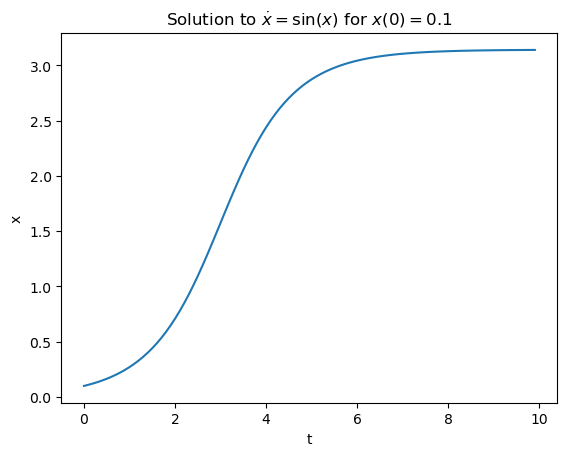

In [3]:
def flow(x, t=None):                # differential equation defining system
    return np.sin(x)                # for `odeint` always provide time t as argument even when not used

x0 = 0.1                            # initial condition
t = np.arange(0, 10, 0.1)           # define time axis
x = odeint(flow, x0, t)             # solve `flow` with initial conditions x0 over time t

# plot solution
plt.plot(t, x)
plt.xlabel('t')
plt.ylabel('x')
plt.title(r'Solution to $\dot{x} = \sin(x)$ for $x(0) = $'+'{}'.format(x0))

Clearly the system has some exponential growth at the beginning but then approaches some stable fixed point for $t \to \infty$. While this is helpful, it doesn't draw a complete picture of what happens in this system. So let's start not from one but several initial conditions

Text(0.5, 1.0, 'Solutions to $\\dot{x} = \\sin(x)$ for various $x(0)$')

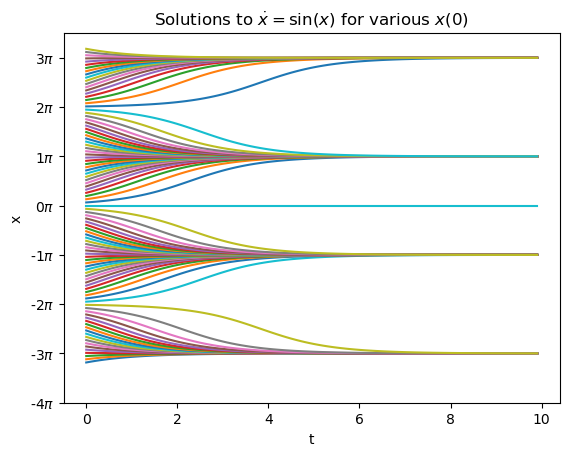

In [4]:
x0 = np.linspace(-10, 10, 99)   # initial conditions are now a vector
x = odeint(flow, x0, t)         # solve again

# plot solution
fig, ax = plt.subplots(1, 1)
plt.plot(t, x)
plt.yticks([i*np.pi for i in range(-4, 4)])                        # Relabel y axis in multiples of pi
ax.set_yticklabels([r'{}$\pi$'.format(i) for i in range(-4, 4)])   
plt.xlabel('t')
plt.ylabel('x')
plt.title(r'Solutions to $\dot{x} = \sin(x)$ for various $x(0)$')

Now we were smart and realised that because of the $\sin(x)$ on the right-hand side of the dynamical system there's probably some periodicity in terms of $\pi$ in the system. Without any assumptions we therefore relabelled the y axis in multiples of $\pi$ and discover:

- Most solutions converge to a fixed point that is odd multiples of $\pi$ from above and below (stable fixed point)
- Most solutions diverge away from even multipiles of $\pi$
- But starting from $x(t=0) = 0$ remains 0, but this fixed point seems unstable!

But note that this required us to actually _solve_ the differential equation. Could we have come to similar (and maybe even more complete conclusions _without_ solving the differential equation? This is an important tool because for many differential equations solving them is not necessarily easy but expensive to do and you may get an incomplete picture of the system, missing some important dynamics that you haven't simulated!

### Graphical analysis of $\dot{x} = \sin{x}$:

A graphical anaylysis can be incredibly helpful as another perspective to _understand the system_ without even solving for it. Let's embrace a more physical interpretation of this system

- Think of $t$ as time, $x$ as position of an imaginary particle moving along the real line and $\dot{x}$ as the velocity of that particle.

Hence, the differential equation $\dot{x} = \sin{x}$ represents a *vector field* on the line. At every point $x$ that particle moves either up or down the real number line or stays where it is. The movement of the particle follows that _vector field_.

In [5]:
image_string = b'...'

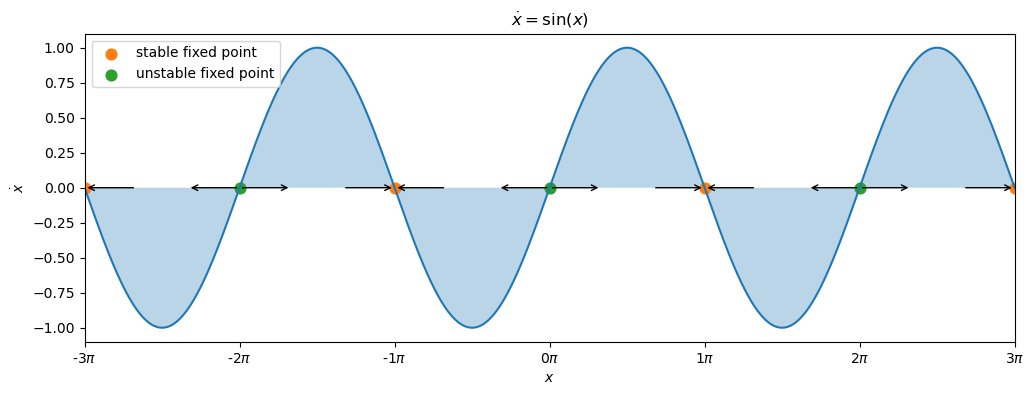

In [6]:
display.Image(b64decode(image_string))

*A more contiuous physical picture...* Think of a fluid flowing along the x axis with a velocity that varies from place to place as $\dot{x} = \sin{x}$.


- Flow is to the right when $\dot{x} > 0$; to the left when $\dot{x}<0$

- Points where $\dot{x} = 0$ are known as __fixed points__

- __Stable__ fixed points have a converging vector field in the surroundings (hence 'attractors' or 'sinks')

- __Unstable__ fixed points have a _diverging_ vector field in the surroundings (hence 'repellers' or 'sources')

Now we can answer the questions in the previous section by starting our imaginary particle at $x_0$ and watching how it is carried along by the flow.

### A (qualitative) analysis of behaviour at $t \to \infty$

$ $1) - Particle starting at $x_0 = \pi/4$ moves to the right faster and faster until it crosses $x = \pi/2$ (where $\sin(x)$ is a maximum). The particle then starts slowing down and eventually approaches the stable fixed point at $x = \pi$ from the left.

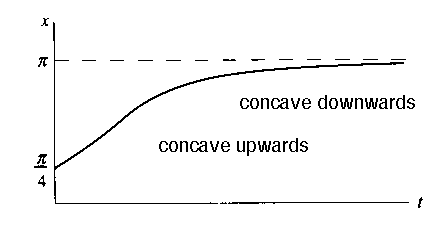

In [7]:
image_string = b'iVBORw0KGgoAAAANSUhEUgAAAbEAAADlCAYAAADduMnkAAABJ2lDQ1BrQ0dDb2xvclNwYWNlQWRvYmVSR0IxOTk4AAAokWNgYFJILCjIYRJgYMjNKykKcndSiIiMUmB/xsDCIMPAwyDEwJWYXFzgGBDgwwAEMBoVfLvGwAiiL+uCzMKUxwu4UlKLk4H0HyDOTi4oKmFgYMwAspXLSwpA7B4gWyQpG8xeAGIXAR0IZG8BsdMh7BNgNRD2HbCakCBnIPsDkM2XBGYzgeziS4ewBUBsqL0gIOiYkp+UqgDyvYahpaWFJol+IAhKUitKQLRzfkFlUWZ6RomCIzCkUhU885L1dBSMDIyMGBhA4Q5R/TkQHJ6MYmcQYgiAEJsjwcDgv5SBgeUPQsykl4FhgQ4DA/9UhJiaIQODgD4Dw745yaVFZVBjGJmMGRgI8QH5CkpCyssMswAAAGxlWElmTU0AKgAAAAgABAEaAAUAAAABAAAAPgEbAAUAAAABAAAARgEoAAMAAAABAAIAAIdpAAQAAAABAAAATgAAAAAAAACWAAAAAQAAAJYAAAABAAKgAgAEAAAAAQAAAbGgAwAEAAAAAQAAAOUAAAAAp76JQQAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAFElJREFUeAHt3Y2S5KgRhdFth9//lcfDOq4XM/ovqQTSqYi2ECSZyZdI11TPzP78+v35ywcBBBBAAIEBCfxrwJyljAACCCCAwN8EiJiNgAACCCAwLAEiNmzpJI4AAgggQMTsAQQQQACBYQkQsWFLJ3EEEEAAASJmDyCAAAIIDEuAiA1bOokjgAACCBAxewABBBBAYFgCRGzY0kkcAQQQQICI2QMIIIAAAsMSIGLDlk7iCCCAAAJEzB5AAAEEEBiWABEbtnQSRwABBBAgYvYAAggggMCwBIjYsKWTOAIIIIAAEbMHEEAAAQSGJUDEhi2dxBFAAAEEhhKxn5+fv8pPPu19+l0RQAABBN5B4OfX789IS61FbLDUR8IsVwQQQGAIAkOdxGqiBKymoY0AAgi8k8CwIvbOclk1AggggEBN4JEiVn/lWC9WGwEEEEDgWQSGErE94rTH9lkltRoEEEDgPQSGErFSlvwurIgUoXrPRrVSBBBAYIrAv6c6e+uLWEXAestPPggggAAC9xAYQsRa8Wrv70EnKgIIIIDA3QSG+zrxbmDiI4AAAgj0Q4CI9VMLmSCAAAII7CRAxHYCY44AAggg0A8BItZPLWSCAAIIILCTABHbCYw5AggggEA/BIhYP7WQCQIIIIDATgJEbCcw5ggggAAC/RAgYv3UQiYIIIAAAjsJELGdwJgjgAACCPRDgIj1UwuZIIAAAgjsJEDEdgJjjgACCCDQDwEi1k8tZIIAAgggsJMAEdsJjDkCCCCAQD8EiFg/tZAJAggggMBOAo8UMf+plp27gDkCCCAwKIFHitigtZA2AggggMBOAkRsJzDmCCCAAAL9ECBi/dRCJggggAACOwkQsZ3AmCOAAAII9EOAiPVTC5kggAACCOwkQMR2AmOOAAIIINAPASLWTy1kggACCCCwkwAR2wmMOQIIIIBAPwSIWD+1kAkCCCCAwE4CRGwnMOYIIIAAAv0QIGL91EImCCCAAAI7CRCxncCYI4AAAgj0Q4CI9VMLmSCAAAII7CRAxHYCY44AAggg0A8BItZPLWSCAAIIILCTwL932n/d/OfnZzGm/3bYIh6DCCCAwKMJdH0SWxOwR1fG4hBAAAEEVgl0fxIrJ62IWdteXR0DBDomkH3dpphvF9rx9Lf2W+9bf1vnHY0r3jzhI0yP8ixZjBBvntbyyM/vxf1aNrl/tBQvadbtpcxGKXjWtbSWqbGj6/t2vJL7kZhH13c0Xpl3JOaRtZVY5fPteEsxP1nH34vxPwjcRKB7EcuDXh6yur3Gq9h6MNcoGUcAAQTGJtD914lj45U9AgggMB6BHBj2Zn7HwWEIEbsDzN7isUcAAQSuIHBUUK7IpUefXYvYXPHST9x63FJyQuB9BPJOetrKyzu2XluP79xuRSzg5qDN9T9tE1kPAgicRyDvlfM8fs/TXe+8u+JuJdutiE0toMAsm7B3qFO560MAgXMI9ChE3knn1PaIl25FbG5TzPUfWbw5CCBwD4EehMi75J7anx21WxE7e6H8IYDAdQS+KUrE57o6juiZiI1YNTkjcDGBb4kSQbq4kC9wT8ReUGRLRKAmcJVAEaSasva3CBCxb5EWB4EvEThTpAjTl4omzGECROwwOhMRuIfAWSJFoO6pn6jnEiBi5/LkDYHTCHwiVgTqtDJw1DkBItZ5gaT3bAKE6tn1tbrrCRCx6xmLgMD//dM9W3E4TW0lxe7NBIjYm6tv7ZcQ2Hu6IlaXlIHTlxAgYi8ptGVeQ2CPYBGra2rA67sJELF319/qdxLYKloEaydY5ggcJEDEDoIz7R0EtogWwXrHXrDKPgkQsT7rIqubCBCtm8ALi8BBAkTsIDjTnkNgTbictJ5Tayt5HgEi9ryaWtEKAaK1AsgwAgMRIGIDFUuqxwkQruPszESgZwJErOfqyO0jAkvC5SvCj9CajEA3BIhYN6WQyBkECNcZFPlAYBwCRGycWsl0hgDhmgGjG4EXECBiLyjyE5dIuJ5YVWtCYD8BIrafmRk3EpgTL7/jurEoQiNwIwEidiN8obcRIFzbOLFC4I0EiNgbqz7ImonXIIWSJgI3EiBiN8IXeprAlHj5unCalV4E3k6AiL19B3Sy/inhKqkRr04KJA0EOiVAxDotzFvSIl5vqbR1InANASJ2DVdeVwhMiZdT1wo0wwgg8AcBIvYHEh1XEiBeV9Ll+wwC2aP+T9U+mndxI2L76sT6IIFs8Hq6l0RNQxsBBI4QIGJHqJmzmQDx2oyKIQIIHCBAxA5AM2WdAPFaZ3SmxVbeW+xiU07KaSfXqdNza1NsW7s9Nu3c4i/zl8am4pa+pU/8xmbKf8Za29Lf2sem7k9fa5/+2Nb3aSd2bMp9xqb61mLU80s7n9pX6atj1O3Ypy/37fz0l+se23re1jYR20qK3SYC7YYtk5Y2+CanjBYJhHnNufSVn7avOGr7WrsEq/tLu3zqvtyX65LPzF2yKT72fub8Fj91rDm/S/PbOXO2pX9LrNbf0n3tM3HrvqW5a2PxV+dc+ub8x772m77WR22Tdmtb7stPPTe2R6//OjrRPARaAtmw6S8b9czNGr+u6wTCva3J+sx/LOKj9NTtfyymW7H9JPa05+t7k/v1keYj1DnU7fkZ146UHNbymBpP/euxtDN2RuZE7AyKL/dRNmS9KctGzWZ9OZrLlx/ua7zn7DIv43sSzpz4mJtbxtdsytzYxG/85T7jpX+qr/THJuOlb+qT8dhP2aRvzjZzMx77nq8l5+S9Jc/WNmtt+7f4is3eHDJv7krE5sjoXyVQNnQ2dYw/2dzx4XoOgbNfFnuymoqd/dLumT1+e7fN/s8ac13r37OuNV+JmWvs6xhlLD91/xXtq+P4ndgVVXuBzzwgWerUg5Ix13cTqPdK9knd9wmds/x8ksNIc2teZ9ei5dD6n4rdzjlyT8SOUHvxnHojFgzZqC9GYukLBLJftu6TYlfmlJ+0i/u5+XP9Cym9dmhvLc4CVdcoOaS+Z8TwdeIZFF/iIxswy603Z/pc+yFQ6tXW7FvZ3Rn7W2sUZz+BK94ZRGx/HV43o30hlY14xWZ8HdgTFpw6rInVnF3mZXxPSpkTH3vmfmq7FLvdr1Oxlua39nO2WXfG23lPvM9as/alNW6pw9L8rWNEbCupl9rVm7Vs4Gzil+IYZtmp2x31moqdvgKwbk8BTc6xy/2Ubdt3ZE7tI/Prvr3t5Btfuc+17d/rv9jP+Zrrr2Mkfumr27XN3vaSn3os7eS5N86Uvd+JTVHR98fmPnPTwXsugVKb8nLICyLe25pttcv8Ldc1nxkvvpJf21fuj3ziJ37jY6u/qfnpi69c0380Vvzcec0aSg5ZR9tX7tc+mRMfxT599dz4KnatbW33afvnd6D1rD+NcsP8Au2hS7ucZr3hSjAcL0cuAAIIHCTgJHYQ3FOn1QJGvJ5aZetC4DkEiNhzavnRSmrxKo4I2Ec4TUYAgS8R8Ac7vgS65zAErOfqyA0BBJYIOIkt0XnBWC1gTl8vKLglIvAwAk5iDyvonuUQsD202CKAQI8EnMR6rMrFOdXiVUI5gV0MnHsEELiMgJPYZWj7dEzA+qyLrBBA4BgBJ7Fj3IacVQuY09eQJZQ0Agg0BJzEGiBPvSVgT62sdSHwbgJE7AX1J2AvKLIlIvBSAkTs4YUnYA8vsOUh8HICfif20A1Qi1dZot+BPbTQloXAywk4iT1wAxCwBxbVkhBAYJKAk9gklnE7awFz+hq3jjJHAIFtBJzEtnEawoqADVEmSSKAwIkEiNiJMO90RcDupC82AgjcRcDXiXeRPyluLV7Fpa8QTwLLDQIIDEHASWyIMk0nScCmuehFAIH3EHASG7TWtYA5fQ1aRGkjgMDHBJzEPkb4fQcE7PvMRUQAgT4JOIn1WZfJrGrxKgZOYJOYdCKAwIsIOIkNUmwCNkihpIkAAl8l4CT2VdzHgtUC5vR1jKFZCCDwTAJOYp3XlYB1XiDpIYDArQScxG7FPx+8Fq9i5QQ2z8oIAgi8l4CTWIe1J2AdFkVKCCDQJQEnsc7KUguY01dnxZEOAgh0R4CIdVKSWrxKSgSsk8JIAwEEuibg68QOykPAOiiCFLokUJ6N9vnoMlFJ3UbASew29P8NXD+gTl83F0N4BBAYjgARu6lktXiVFAjYTYUQFgEEhiZAxG4oHwH7f+gtjzI6Jepb7GJT5qedaJ/6jJ+p/BJrKcbS2JTPOl7dnovV9tf3acdPm0vG6/70tbmlf852S4wtPmr/8Zlr5ud+yTY2rs8kQMS+XNf64fPg/fU/oalZFEblp+0rpWr7WruUs+4v7fKp+3Jfrks+M3fJpvjY+5nzW/zUsfb6nbKfWnfbNzVva9/cWuZixL72n7567emr7Uo7/bEt9+Un9629+2cT8Ac7vlTfPGgJ54ELiT+vYZOX1Z8W6z3xUSzr9trM2H4Sey3Gt8ezpm/HXYpXclrLa2o8danH0s7YUlxjzyNAxL5Q0/bhykP3hdBdhwiXNR5zdpmX8T2LzZz4mJtbxtdsytzYxG/85T7jpX+qr/THJuOl74rP2XGKv/jckm9rm/W2/Vt8xWZvDpnnOj4BXydeWMM8nAnxyUMaH2+53slqKnZby6fVoay5rLH8pF3WmPZUf8vgm4wSa6pWbV7un02AiF1U3zxkce9hC4mxrnUdU8O675PVnOXnkxzOmFuv42xGbX6t/6nY7Rz3zyZAxC6orwfrAqg3uEwd8+JcS6HYlTnlJ+0yZ27+XP9anJ7G9zI6K/eaXXII97Ni8DMGASJ2Yp3yMMVl/aClz3UbgbC8g2Fib8uU1d0Eyh5Rs7urcF98f7DjJPb1Q1Qeqjtevict5WtuwqhmNxV8zi7zMj41d64vc+Jjzu6K/qXYJZ+rc4r/5HHFGvf4TB7Ja2nuN/gsxTfWHwEi9mFN2ocqD+SHbl89PS+zO1hOxU5fKUrdnipSco5d7qds2769c2Jf/NTtOb9tf3ufXOMr97m2/fX8jJW+ul3b7G0v+anH0k6ee+OwH5vAz+/C/xp7CdPZl4199dLy8CSDq+MlztOuLceyvimWW+xi085f66+Z1nMzL+NlrO6rbWOzNj5ll74pfxmrr3WM0l/nFR+xqcfiIza5zzVzyn1tM9df7OqxzKv74id9uS+29Sfj6St26WvnpL+2Tdv1XQSI2IF6e4AOQDPl6wSyT1sB+HoiAiJwIQFfJ+6EmxdDpnlBhIQrAggg8H0C3f/pxFY0akTfFJA2j2/GrtesjQACCCDwD4GuT2KtcPyT9ndbbR4E7Lv8RUMAAQTmCHR7EmuFo13AN4SkzeEbMdt1ukfgKAH79Sg580Yi0O1JrDyA9UM4174KNgG7iiy/CCCAwHkEuj2J1Uv8poARr5q8NgIIINA3gW5PYgVbLSh1+yqkbYxaPK+KyS8CCCCAwHECQ5zEji9v20zitY0TKwQQQKA3At2exCIsU6ehjJ0Bs/U1Fe+MOHwggAACCJxPoMuTWCss9bKXxmq7tXbrh3itETOOAAII9EegSxELpjlhmevPvKVrK17F9hN/S7GMIYAAAghcS6BLEZsSlam+vWhaATvD594c2COAAAIInEegSxEryyuCU0TmDOE5w8d5yHlCAAEEEDiLQDf/in0rNFsWuHSSmvO3NGdLTDYIIIAAAv0Q6PYkdjYi4nU2Uf4QQACB+wl0I2JXisyVvu8voQwQQACB9xLo9u+JnVUSAnYWSX4QQACB/gg8WsQIWH8bTkYIIIDAmQQeLWJnguILAQQQQKA/AkSsv5rICAEEEEBgIwEithEUMwQQQACB/ggQsf5qIiMEEEAAgY0EhhKxub/AvHGtzBBAAAEEHkZgGBEjYA/beZaDAAIInEBgCBE7KmBH553AlQsEEEAAgS8QGELEjnLw98SOkjMPAQQQGINA9yJWTlNFjAjSGBtKlggggMA3CXQtYhGwbwIRCwEEEEBgHAJdi9inGP1O7FOC5iOAAAJ9E+jmX7FvMUWAcs2401lIuCKAAAIIDHkSa4VNGRFAAAEE3kmg25NY+wc5auFqx95ZOqtGAAEEEBjmJEa4bFYEEEAAgZbAMCKWxIlZSLgigAACCAwlYgTMhkUAAQQQqAkMJWJ14toIIIAAAggQMXsAAQQQQGBYAkRs2NJJHAEEEECAiNkDCCCAAALDEiBiw5ZO4ggggAACRMweQAABBBAYlgARG7Z0EkcAAQQQIGL2AAIIIIDAsAQeK2L+YvSwe1LiCCCAwGYCjxWx+h8M3kyDIQIIIIDArQT2vrsfK2K3VkFwBBBAAIHdBPYKWAnwWBHzdeLu/WMCAgggcBuBWsDq9lpCjxWxtYUbRwABBBDok8CeQwgR67OGskIAAQReSWCPgBVA3f6XnV9ZPYselkD5+mPPw1fb1+0CoL4vbR8ERiaw57k4ss6f3wF+HZk4whwvgBGq9I4c85gt7cliszRek9pjW89baifHYlPySIy6f2p+cl6zm5qrD4EQOLqPHi1igeOKAAIIINAvgaMCVlbkd2L91lVmCCCAAAIrBIjYCiDDCCCAAALfIZAT2Z5oRGwPLbYIIIAAApcROPJ7VX868bJycIwAAgggsIXAEfGKXyexkHBFAAEEEBiOABEbrmQSRgABBBAIASIWEq4IIIAAAsMRIGLDlUzCCCCAAAIhQMRCwhUBBBBAYDgCRGy4kkkYAQQQQCAEiFhIuCKAAAIIDEeAiA1XMgkjgAACCIQAEQsJVwQQQACB4QgQseFKJmEEEEAAgRAgYiHhigACCCAwHAEiNlzJJIwAAgggEAJELCRcEUAAAQSGI0DEhiuZhBFAAAEEQoCIhYQrAggggMBwBIjYcCWTMAIIIIBACBCxkHBFAAEEEBiOABEbrmQSRgABBBAIASIWEq4IIIAAAsMRIGLDlUzCCCCAAAIh8B/Pnc3LmBOMcAAAAABJRU5ErkJggg=='
display.Image(b64decode(image_string))

Already by looking at the previous figure we can conclude

- Starting at $x(t=0) = \pi / 4$ the rate of change $\dot{x}$ is positive, so the particle will accelerate (its time series will bend concave upwards
- Eventually it will cross the inflection point at $\pi/2$ where it will start to decelerate (time series will bend concave downwards)
- Because this is a 1D continuous autonomous system, there's no memory, it's impossible to cross a stable fixed point

$ $2) Same reasoning applies to any $x_0$ and we could have very easily drawn a __qualitative__ picture what required us 100 integrations of a differential equation (Figure before) by hand

Text(0, 0.5, 'x')

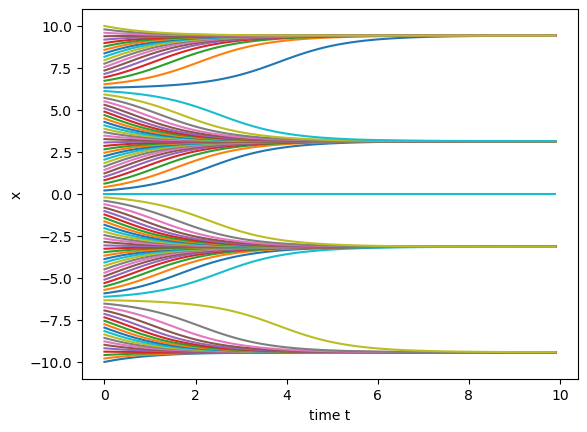

In [8]:
x0 = np.linspace(-10, 10, 99)
x = odeint(flow, x0, t)
plt.plot(t, x)
plt.xlabel('time t')
plt.ylabel('x')

A __qualitative__ understanding is sufficient to start with! And in many cases indeed a very good starting point!

## Fixed points and Stability

$ $Consider a general 1-dimensional system $\dot{x} = f(x)$. Note *f* is independent of $t$, which makes this system also _autonomous_.

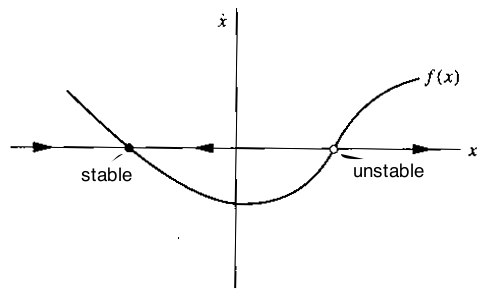

In [9]:
image_string = '...'
display.Image(b64decode(image_string))

- To *find the solution to* $\dot{x} = f(x)$ given $x = x_0$ at $t = 0$ we place an imaginary particle (a phase point) at $x_0$ and watch how it is carried along by the fluid flow.
- As the imaginary particle moves along the x axis, its *trajectory* (position as a function of time) is given by x(t).
- A picture which shows all the qualitatively different trajectories of the system is called the *phase portrait*, e.g. the figure we used for our graphical analysis of sin x
- The appearance of the phase portrait is controlled by the fixed points $x^*$ defined by $f(x^*) = 0$
- Fixed points represent (stable or unstable) equilibrium solutions of $\dot{x} = f(x)$


#### Example: a simple function

For the function $\dot{x} = x^2 - 1$,

$ $1) Find all the fixed points and 

$ $2) Classify their stability.

#### Answer

In general such questions can be solved graphically or mathematically. 

- Fixed points obtained from $f(x^*) = 0 \Rightarrow x^* = \pm 1$
- Stability obtained from vector field sketch

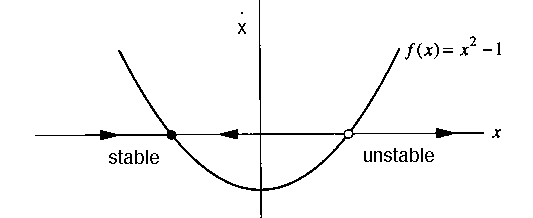

In [10]:
image_string = b'iVBORw0KGgoAAAANSUhEUgAAAhUAAADaCAYAAAARxbA2AAABJ2lDQ1BrQ0dDb2xvclNwYWNlQWRvYmVSR0IxOTk4AAAokWNgYFJILCjIYRJgYMjNKykKcndSiIiMUmB/xsDCIMPAwyDIIJSYXFzgGBDgwwAEMBoVfLvGwAiiL+uCzMKUxwu4UlKLk4H0HyDOTi4oKmFgYMwAspXLSwpA7B4gWyQpG8xeAGIXAR0IZG8BsdMh7BNgNRD2HbCakCBnIPsDkM2XBGYzgeziS4ewBUBsqL0gIOiYkp+UqgDyvYahpaWFJol+IAhKUitKQLRzfkFlUWZ6RomCIzCkUhU885L1dBSMDIyMGBhA4Q5R/TkQHJ6MYmcQYgiAEJsjwcDgv5SBgeUPQsykl4FhgQ4DA/9UhJiaIQODgD4Dw745yaVFZVBjGJmMGRgI8QEHAkpJ5RwfZwAAAGxlWElmTU0AKgAAAAgABAEaAAUAAAABAAAAPgEbAAUAAAABAAAARgEoAAMAAAABAAIAAIdpAAQAAAABAAAATgAAAAAAAACWAAAAAQAAAJYAAAABAAKgAgAEAAAAAQAAAhWgAwAEAAAAAQAAANoAAAAAiW6lqQAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAGHpJREFUeAHt3Ymy27gRheFxKu//ys4gmXbaMCWRFEhi+W6VSyQI9PI3lkP5jufHz79//vKDAALLE/jx48dftoPlpwEACHxF4F9fjTYYAQQQQAABBBD4hwBRYSoggAACCCCAQBMCREUTjIwggAACCCCAAFFhDiCAAAIIIIBAEwJERROMjCCAAAIIIIAAUWEOIIAAAggggEATAkRFE4yMIIAAAggggABRYQ4ggAACCCCAQBMCREUTjIwggAACCCCAAFFhDiCAAAIIIIBAEwJERROMjCCAAAIIIIAAUWEOIDA4gfL/7Ch//CCAAAJPEyAqnq4A/wgggAACCExC4N+T5CENBJYl4P8sumzpJY5AdwR8U9FdSQSEAAIIIIDAmASIijHrJmoEEEAAAQS6I0BUdFcSASGAAAIIIDAmAaJizLqJGgEEEEAAge4IEBXdlURACCCAAAIIjEmAqBizbqJGAAEEEECgOwJERXclERACCCCAAAJjEiAqxqybqBFAAAEEEOiOAFHRXUkEhMBnAq/+ae5X7Z8t6oEAAgh8T4Co+J4hCwjcTiD+Fc38//yI63h2e1AcIoDA8gSIiuWnAAAIIIAAAgi0IUBUtOHICgK3E4hvJPJfeUTb7cFwiAACCPxNgKgwDRAYmEAWEfl64JSEjgACAxMgKgYuntARQAABBBDoiQBR0VM1xILAQQLxy5llWL4+aEZ3BBBAoAkBoqIJRkYQeI6Av/Z4jj3PCCDwOwGi4nce7hAYhkD+ZiKERW4bJhGBIoDANASIimlKKZGVCIR4CDFRco/reLYSD7kigEAfBIiKPuogCgQQQAABBIYn8O/hM5AAAgsSiG8l6tRftdf93COAAAJXEPBNxRVU2UQAAQQQQGBBAkTFgkWXMgIIIIDA9QTK7zet9jtORMX184oHBBBAAIGFCNRiYiVhQVQsNNGligACCCBwD4Hy+03xp3hcRVgQFffML14QQAABBBYhsPIvTBMVi0xyaSKAAAIIPEdgFaFBVDw3x3hGAAEEEJicwCp/7RFlJCqChE8EEEAAAQQuIHDHtxS9iBf/+NUFE4hJBBBAAIE/CeSD79VBW/q8evanxf+1hN2j417Za9V+JpejviP3o+Ou6u+biqvIsosAAggg8ItAHH6vDv7y/OwhHDbDxy+nD17kWCK3K8KJ3K+wfcYmUXGGmjEITEogb4STpiitBwjEvIoDMD7rUF611/227mNs+Nrqc1dbjiFf3+X/ST/++uNJ+nwj0BmB2Jg7C0s4kxOY7eBdeR0RFZMvVukhgAACTxGoxUK5P3PgZjsxPtrivuRYrkv7WT97OYXv7DPG5niibaVPomKlassVgQ8Ert6MP7j3eBACcah+OkDjkI+0tvrvsZXtRP9ic8te+Ko/87j6Wb7fY3Mrnj3jsp9Zr4mKWSsrLwQQQKAjAi0P3TO2zozZi6+F7T2ip4WfvTmd7ecXNc+S63xcmaB7JmnnaQgPAQQ6I/DUvtLbgdpbPL1ME99U9FKJi+IoG4DJfxFcZhFYmMBo+8peMbQ3r7329k6RvX732nuqn28qniJ/sd88QVtP/otDZx4BBDol8ORe8qTvTsvRZVi+qeiyLIJCAAEE+iWQX1reRRlC4F3/8qz0K39e9Qs74SvuX/WPfvnzSN88bus6Yo044rOljy2/I7T5pmKEKp2MMU/wmPQnTRmGAAKLE3hiDyk+w2/Zz/Ke9q4ce/u9s7H1LMdTnl/lZ8v3q7bgU57n61f9r273TcXVhNlHAAEEJiJwxUFabL47ELd8brW9s9GqBFt+t9pa+ftk50nfW7H5pmKLykRtecLdseAmQicVBBD4h8A3e0fegz4Brf2UsfX4rbZst+6fn317vWV7q+1bPyOPJypGrp7YEUAAgRsJ7DlAQxjE597wwvbRcWG/jAsb0ebzfgJExf3Mb/eYF9rZBXt70BwigEAXBM7sGTEm7z17kjnaP2wSFEHi+U+i4vkaiAABBBDonsDeAz/6xefRxM6MOzPmaFz67yNAVOzjNHyvvOjiLWL4pCSAAAKXEji7V+T95tIAGe+OAFHRXUmuC8hCv44tywjMTMDeMXN12+ZGVLTlOYy1s28gwyQoUAQQ+IqAPeIrfMsOJioWK703jsUKLl0EviRgz/gS4GLDiYrFCp7T9SaSabhGAIEgYG8IEj6PEiAqjhKboL83jwmKKAUEbiBgr7gB8mQuiIrJCno0HW8kR4npj8DcBOwJc9f36uyIiqsJd2rfG0inhREWAp0QsEd0UojBwiAqBivYFeF6M7mCKpsIjEfAXjBezXqLmKjorSI3xpPfRGwmN4LnCoHOCeS9ofNQhdcZAaKis4IIBwEEEHiCgBeLJ6jP55OomK+mhzLKbyQ2lUPodEZgSgJ5T5gyQUldSoCouBQv4wgggED/BLxQ9F+jUSIkKkap1IVx5jcTm8uFoJlGoEMCec3nvaDDUIU0AAGiYoAi3RGizeQOynwg0C8Be0C/tRkpMqJipGrdFGt+c7nJJTcIIPAAAWv9AeiTuyQqJi/wkfS8qRyhpS8C8xCw9uep5dOZEBVPV6BT/95gOi2MsBBoRMAabwSSmd8IEBW/4XDjjcUcQGAtAtb8WvW+Olui4mrCA9v3JjNw8YSOwBsC1vYbOB59RYCo+ArfnIPzm4vNZ84aywqBQiCvdUQQaEGAqGhBcUIbNpsJiyolBP4m4EXBNLiSAFFxJd1JbNuEJimkNBBIBLw4JBgumxEgKpqhnM+QTWe+mspobQJeENau/x3ZExV3UJ7Ah81ogiJKAYF/CHhhMBWuIkBUXEV2Ert58yEsJimqNJYkEOs3r+klQUj6UgJExaV4GUcAAQSeJxCC4vlIRDA7AaJi9go3yC+/2dicGgBlAoGHCOS1/FAI3E5OgKiYvMCt0rMZtSLJDgL3EvAicC/v1b0RFavPgBP526ROQDMEgQcI5LXqxeCBAizokqhYsOhnU86bUt6sztozDgEEEEBgLgJExVz1lA0CCCDwXwJZ+OcXAngQuJIAUXEl3Qlt580pb1oTpiolBKYgkNfsFAlJomsCREXX5ekzOJtUn3URFQJBgOAPEj7vJkBU3E18Mn82r8kKKp2pCHgBmKqcQyRDVAxRpv6CzJsVYdFffUS0LgHrcd3a95A5UdFDFcSAAAIINCCQBUUW/g1MM4HALgJExS5MOm0RyJtW3sy2+mpDAIH7COS1eZ9XnhD46y+iwiz4ioDN6yt8BiPQjABh3wwlQ18QICq+gGfo7wRsar/zcIfAXQTy2iP076LOzxYBomKLirZDBPImlje3Q0Z0fpxAruPjwQgAAQSGJEBUDFm2/oJ2IPVXExGtQSALeetwjZr3nCVR0XN1Bo0tb3KDpiBsBIYjQFAMV7IpAyYqpizrM0nlTY2weKYGvK5FwDpbq94jZEtUjFClgWLMwmKgsIWKwHAEsqCw7oYr37QBExXTlvb5xPKm93w0IkAAAQQQuJoAUXE14QXt57cmwmLBCSDlywnkdZXX2+WOOUDgAwGi4gMgjxFAAIFeCRAUvVZm3biIinVrf2nmebPLb1WXOmUcgQUIWE8LFHngFImKgYvXe+iERe8VEt9oBLKgyOtrtDzEOy8BomLe2soMAQQmJUBQTFrYCdIiKiYoYs8p5M0vv2X1HLPYEOiRgPXTY1XEVBMgKmoi7psTICyaI2VwMQJZUOT1tBgG6Q5AgKgYoEhCRAABBAoBgsI86J0AUdF7hSaJL2+G+a1rkvSkgcBlBKyXy9AyfAEBouICqExuEyAstrloReAVgSwo8vp51V87Ak8TICqergD/CCCAwAcCBMUHQB53Q4Co6KYUawSSN8f8FrZG9rJEYD8B62M/Kz37IUBU9FOLZSIhLJYptURPEsiCIq+Xk+YMQ+A2AkTFbag5ygTyRpk30NzHNQIrEsjrIa+TFVnIeTwCRMV4NRMxAggggAACXRIgKrosyxpB5bew/Ha2RvayROBPAnkd5PXxZ08tCPRJgKjosy7LRJU3zryhLgNAogj8QyDP/7wuAEJgJAJExUjVmjRWG+ikhZUWAggsR4CoWK7kfSec39b6jlR0CLQjkOc9kd2OK0v3EyAq7mfO4waBvJHmDXajqyYEpiKQ53teB1MlKZllCBAVy5S6/0Tzhpo32v4jFyEC3xPI8/97aywg8AwBouIZ7rwigAACfxHPJsFsBIiK2So6eD75bc2GO3gxhf+WQJ7fed6/HeThWwKFafx529HDywj8+zLLDCNwkkDZYGPDLZ823P+DDC6Y/J/JKFdRuzpetayJtLmvec/GOfKLvOr7NhSPWyEqjjO7dERMjOIkJsulDjs1XnIPFvEZoa7Epc49GPgch4Aa9lGrug6z7CN1Xk/TJiqersAb//VkmWURvEl516PgMiOPyG0XCJ26JxD13Jqr8az7JCYNsOa/VaOeUy/x5hx6iZ+o6HnWVLHlCVQe9TKJqjBvuy08RmdQ1/Q2eBzdRuDVHC3t6t+uDN+y/HZ8i0xezZVPts+O+2T3zHOi4gy1TsbUi6CnidUJou7CqGt2NsBiJ9f7ld3oE8/LfVy/8v3p+atx2s8RwPscN6P6JPDj703mZ5+hjRuVTWLc2okcgT0E9oizsPNui817xbt+YcvnewKZ5/ue209HqkHOtae4u/qmIkPaLrlWBP4k0NOC+jO6P1tazPOrci6xXWX7TxJjt+zh9K7W8WyPnbFJ9R39DPx7WrddiYoZivvt8omN5qydmRjuYTFivnXMe/I8Ox+Me55ATxv+8zSejaBee89Gc9x73isil2jrZZ51JSqOIzYiJhYS4xKoaxibxLgZibwm8Kqmde3rce6/JzAj462cttq+p3fcAlFxnNmjI3qZOHdAKLm+2ozv8P+Uj7rGKzJ4in1Lv+/qVte4pd+Vbc3OdSu/rbYn5wBR8ST9Hb57mzA7Qm7aJfLPG3Rpi/vyGX2aOu7I2Oz5dYS6WSgxP4tB9WuGlaEBCBAVnRXJBrRdkJpLuY+NewVhsU1FKwIIINAXAf9Dsb7qIZoDBLLQCIFxYLiuCFxCIM/FPEcvccYoAp0RICo6K4hwjhHIm3bezI9Z0RuBNgTyHMxzs411VhDonwBR0X+NRPiBQN6886b+YZjHCDQlkOdenpNNnTCGQOcEiIrOCyQ8BBDonwBB0X+NRHgPAaLiHs68XEwgvxnmDf5it8wj8OsXhguKPA+hQWBFAkTFilWfNOe8oRMWkxa5s7TyPMvzr7MwhYPAbQSIittQc3QHgbyx5w3/Dt98IIAAAqsTICpWnwET5k9YTFjUDlPKojXPuQ5D/TqkkmvO96jBI+OP9D0ah/7XEyAqrmfMwwME8ib/zWb4QOhcdk6gPvTyXOs8dOEhcDkBouJyxM85qDe/o5EcGX+k79E4zvbPm32Jzw8CrQnkOdbaNnsIjEjAP9M9YtXEvJtA2fRDUJRPh8BudDpuEIi5VB49MZfCf+27bs/3cR3p1GNL+7s++VlcZxvRFvbLZ36e28t13f9d33djj4yr7bi/joBvKq5jy3InBPLmU29onYQojAEI5LmT51TPoZeYS6w53pxHiT3uc79oK8/z2Nxna2z0zeNLv/gp7WHjU98YUz7LuHpstOV+rp8n4JuK52twOoKyqPJPLNLSlp/F9avnYSM/j7b4DBtx/65v9InPPPbIuBjf4rP4jTjK51NxtMiFjfsJxNwpnkeaOznWvAaCYOS11e+KdZL9RAw+5yLgm4pB65k3g1io0VZSira4zvfRr7TFn9Iv2st1/int0S/svOpbj6vHlvs9Y7OdVtcRe7H3VAytcmHnPgJ5ruQ5dF8E93uK9f7J895+r+wEz8y47hvPom88j/t4Hu0+nyVAVDzL/5T3WESxqIqRuI5npwy/GBS2XzweqjnncgWroWAI9iOBPEfy3Pk4cLAOJc+c69HwY/w3No761L9PAv76o8+6nIpq76a3t9+rIMr42ERe2YrNpX6+Z+wrv63aI4Zir8RZx9jKDztjE4g5XLKYdY5EXpFrfO7Neat/bms5A66y2zJGtv76i6gYeBbEIouN4WgqMf7ouBn6F2aRf/k8y3AGFnL4k0DMjfJkhbmRc4zcP62L6JfH/kmyXctdftpFvKYlomLAusfiikUdnyWVePYura3+ue3d2KPPrrJ7NI6t/oVVxFc+97DbsqNtLgIxJ0pWK86JvC7mqqxs7iBAVNxB+SIfecOLjfDT4Rj98tiLwvuv2bv8nM0hb6B3szkbs3HXEYg5UDz0PndbUIh8n8p1j/9Yo6VvHeee8S04sbGfgF/U3M+q6571Yus62M6Cq9nFRtVZmMK5kECpea57PScudH3KdI41X58y9vegbCOu9zKI/sV3vt6K5dPzrTGv2sLW3jhf2dHelgBR0ZbnLdbKYooFdYvDykn4freY41n0zSaejj/HEtcRb9xvxR3PfM5NoJ4LPWWbY4t1lNuOxlrGxviwV2xEW9iL+1d9oj36lXGlrf4pz6NvPM9j6v5xH33OjA0bPu8h8OPvYv28xxUvrQjEYiz2onzRFvfl2bu2rbG5LY9/1b7X16d+xX4vP8Es4smxR9vMnyX/lXJevd4zz2W5PUOAqHiGexOvezbE3CcOi9xWAintua3uVz+PMTmJGB9j41m0x/3W2Pysh+s65jqnHmK8KobIfYWcI9dguULOkatPBK4iQFRcRZbdoQmseuCUvFc4XFet79CLUvBDEPBffwxRJkHeTSAO1jh84jPa746Hv3YEopbFonq248oSAoWAX9Q0DxB4Q6A+dPKB9GaYR50SyPWra9tpyMJCYCgCRMVQ5RLsEwTqwycfTE/Ec7XPGfMrOeW86ppezZR9BFYhQFSsUml5fkWgHEL5IMoH1FeGDb6cQF2rXMfLnXOAwGIEiIrFCi7d7wjkA6l++/3OstFXECAorqDKJgKvCRAVr9l4gsAmgSwsSof64NocpPFWArXgKzWr63ZrQJwhsAgBomKRQkuzLYH6gKoPsbbeWDtCoBZ5da2O2NIXAQSOESAqjvHSG4FfBLbefusD7VdnF5cT2BJ2BMXl2DlA4DcCRMVvONwgcJxAfXBtHW7HrRpxhEAt5rYE3xF7+iKAwDkCRMU5bkYh8BuBrUOsPuh+G+CmGYGacy3ymjliCAEEPhLwL2p+RKQDAvsJlAMtH3Jx7aDbz3Bvz2Ab/TEOEj4ReI6AbyqeY8/zpATK4VYfcPUBOGnqt6RVWNY8a963BMIJAgj8QcA3FX8g0YBAGwLloMuHX1w7AM/xDX55NJaZhmsEnidAVDxfAxFMTCAOvXwgxnU8mzj9ZqkFszCIXZDwiUBfBIiKvuohmkkJxCGYD8e4jmeTpv5VWsEoG8Er03CNQF8EiIq+6iGayQnEgZgPy7iOZ5Mj2JVeMMmd8ck0XCPQJwGios+6iGpyAnFA5sMzruPZ5Ag20wsG+eHKPDIH1wiMQICoGKFKYpyWQDkw64M07lc5TCPfusir5F/n7R6BkQkQFSNXT+xTEIjDsz5c4z6eT5FsSiLyS03/vZw13zpP9wjMSIComLGqchqSQD5M84Gbr3OfEZPMudTxj55bnY97BFYkQFSsWHU5d08gDtj6EM730af3ZHLMW7GOksdW7NoQQOB3AkTF7zzcIdAVgXzg1odzfZ/7Pp1EHVsdT0+x1rG5RwCB8wSIivPsjETgVgL5IN46tLfa8pirgt3yu+Xrjli2/GpDAIH7CBAV97HmCYFmBPIB/e5Qf/esBJPt1MF9Glv337p/Z3+rvzYEEBibwI+/F/3PsVMQPQII1ARaCILa5qd7W8knQp4jMD8B31TMX2MZLkhg64BvJTS2bC+IWMoIILBBgKjYgKIJgRkJ7BEDITz29J2RkZwQQOA7Av/6brjRCCCAAAIIIIDA/wgQFWYCAggggAACCDQhQFQ0wcgIAggggAACCBAV5gACCCCAAAIINCFAVDTByAgCCCCAAAIIEBXmAAIIIIAAAgg0IUBUNMHICAIIIIAAAggQFeYAAggggAACCDQhQFQ0wcgIAggggAACCBAV5gACCCCAAAIINCFAVDTByAgCCCCAAAIIEBXmAAIIIIAAAgg0IUBUNMHICAIIIIAAAggQFeYAAggggAACCDQhQFQ0wcgIAggggAACCBAV5gACCCCAAAIINCFAVDTByAgCCCCAAAIIEBXmAAIIIIAAAgg0IUBUNMHICAIIIIAAAggQFeYAAggggAACCDQhQFQ0wcgIAggggAACCBAV5gACCCCAAAIINCFAVDTByAgCCCCAAAIIEBXmAAII/CLw8+fPX9cuEEAAgaMEiIqjxPRHAAEEEEAAgU0CRMUmFo0IrEngx48fayYuawQQaELgP2wYGl/ZZk3dAAAAAElFTkSuQmCC'
display.Image(b64decode(image_string))

- Definition of stable equilibrium is based on small disturbances, hence $x^* = -1$ is *locally* but not *globally* stable.
- Here you if you add a perturbation $\varepsilon = 10$ then the "stable" fixed point is not stable anymore

#### Example: Population Growth

Verhulst (1838) suggested the logistic equation (this is a continuous version of the logistic map we saw in the previous lecture)

$$ \dot{N} = rN\left(1 - \frac{N}{K}\right) $$

where $N(t)$ is the population at time $t$, $r$ is the growth rate (r > 0) and $K > 0$ represents the carrying capacity of the population

- $ K \rightarrow \infty \Rightarrow N(t) \propto e^{rt} $ hence population keeps growing. Maybe no surprise if the carrying capacity goes to infinity.
- Finite K models the effect of overcrowding and limited resources

For the logistic equation,

1) Find all the fixed points and
2) Classify their stability.

Let's solve this problem graphically. Some hints

- The equation is quadratic in $N$ with a negative sign
- $N = 0$ and $N = K$ are both fixed points (feel free to solve for $\dot{N} = 0$ first)

This already allows you to draw the following graph

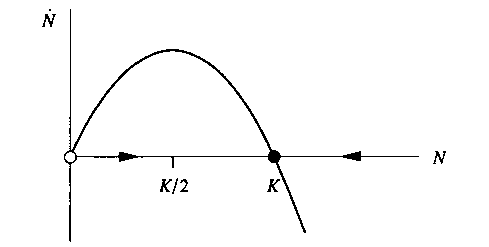

In [11]:
image_string = b'iVBORw0KGgoAAAANSUhEUgAAAekAAAD3CAYAAAA5ZazIAAABJ2lDQ1BrQ0dDb2xvclNwYWNlQWRvYmVSR0IxOTk4AAAokWNgYFJILCjIYRJgYMjNKykKcndSiIiMUmB/xsDCIMPAwyDAYJmYXFzgGBDgwwAEMBoVfLvGwAiiL+uCzMKUxwu4UlKLk4H0HyDOTi4oKmFgYMwAspXLSwpA7B4gWyQpG8xeAGIXAR0IZG8BsdMh7BNgNRD2HbCakCBnIPsDkM2XBGYzgeziS4ewBUBsqL0gIOiYkp+UqgDyvYahpaWFJol+IAhKUitKQLRzfkFlUWZ6RomCIzCkUhU885L1dBSMDIyMGBhA4Q5R/TkQHJ6MYmcQYgiAEJsjwcDgv5SBgeUPQsykl4FhgQ4DA/9UhJiaIQODgD4Dw745yaVFZVBjGJmMGRgI8QFSjkpv/YrtDQAAAGxlWElmTU0AKgAAAAgABAEaAAUAAAABAAAAPgEbAAUAAAABAAAARgEoAAMAAAABAAIAAIdpAAQAAAABAAAATgAAAAAAAACWAAAAAQAAAJYAAAABAAKgAgAEAAAAAQAAAemgAwAEAAAAAQAAAPcAAAAAEZn+tAAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAFfpJREFUeAHt3YmO3LYSBdD4If//y36WEzo1HKq1U1xOAGO6tXA5xeYdNZL4x89f//zlHwIECBAgQKA5gf81NyIDIkCAAAECBH4LCGkLgQABAgQINCogpBstjGERIECAAAEhbQ0QIECAAIFGBYR0o4UxLAIECBAgIKStAQIECBAg0KiAkG60MIZFgAABAgSEtDVAgAABAgQaFRgipH/8+PHX8ufOf+5u786xaYsAAQIE5hAYIqTnKJVZEiBAgMBsAn+PMGH/Z9MRqmgOBAgQIJALeJLORbwnQIAAAQKNCAjpRgphGAQIECBAIBfo8uvu+C915V91x3PLZPPzOYD3BAgQIECgVYHhnqRjKMfXrRbAuAgQIECAwJpA9yGdPzmvTdRxAgQIECDQm0D3Ib0G7il6TcZxAgQIEOhFYIiQjk/T8XUvRTBOAgQIECBQEug2pJcnZU/LpZI6RoAAAQKjCHQX0nuelIX3KMvTPAgQIDC3QJf/CVapZHvCu3SfYwQIECBAoFWB7p6kF8j4pBxft4psXAQIECBA4IxAVyHtaflMid1DgAABAr0KdBXSa8jxaTq+XrvecQIECBAg0IPAECHdA7QxEiBAgACBowLdhLSvuo+W1vUECBAg0LtAN/9299bX2Fvney+U8RMgQIDAfALdPEnPVxozJkCAAIHZBYT07CvA/AkQIECgWQEh3WxpDIwAAQIEZhcQ0rOvAPMnQIAAgWYFhHSzpTEwAgQIEJhdQEjPvgLMnwABAgSaFRDSzZbGwAgQIEBgdgEhPfsKMH8CBAgQaFZASDdbGgMjQIAAgdkFhPTsK8D8CRAgQKBZASHdbGkMjAABAgRmFxDSs68A8ydAgACBZgWEdLOlMTACBAgQmF1ASM++AsyfAAECBJoVENLNlsbACBAgQGB2ASE9+wowfwIECBBoVkBIN1saAyNAgACB2QWE9OwrwPwJECBAoFkBId1saQyMAAECBGYXENKzrwDzJ0CAAIFmBYR0s6UxMAIECBCYXeDv2QHMv02BHz9+HB7Yz58/D9/jBgIECLQsIKRbrs4kYzsTyCWaUjuCuyTlGAECvQgI6V4qNdA4S2G6Nb1S2O5pJ15TamOrX+cJECDwpoCQflN/or5jWK5N+2iIfrq+1F9+7NP9a2N0nAABAjUFhHRN7Qn7yoMxEjwZknnbpXGkY/m1cYxeEyBA4E0BIf2m/sB9pwDMp/hWIMZ+87Gl9/GafNzeEyBA4A0BIf2G+sB9psCLU2wt/NJ48rGm9+l8nIPXBAgQeENASL+hPlifKdzyabUednF8cQ7xdbwmn5/3BAgQeFrA/8zkaeHB24+Blqa6BFtv4bY25tL80jz9JECAwNMCnqSfFh60/VJ49RbMpdKkOcT5pdfpXOk+xwgQIPCEgJB+QnXgNlNgxSmOGF5pTnG+6XU6Fw28JkCAwBMCvu5+QnXQNlNIpektYTV6YJXmmDskDz8JECBwt4CQvlt0wPaWUMqDafRwzsuYz7dkkt/jPQECBK4K+Lr7quDA9+fBvEw1D6uBp/9tamnu0SW9Tue+3eQAAQIELgh4kr6AN/KtKXziHAXRPxqLQ25R8op2XhMgQOCMgJA+ozb4PXnglEJpcIJd0xPUu5hcRIDABQFfd1/AG+3WUjiPNse757MEdXRLr/MAv7tf7REgMIeAJ+k56rw5yxQu6UIhkyS2fy5WuVfuud2KKwgQIPBdQEh/N5nuSB4oeeBMB3Jywrlb7nqyWbcRIDCxgJCeuPjL1GOQlJ4IJ+c5PH1BfZjMDQQIfBAQ0h9wRj61hHMe0CPPt+bc8l92onPNceiLAIH+BYR0/zU8PIM8NPKnv8MNuqEoEF3zX4qKNzhIgACBTEBIZyCjvxXQdSscg7puz3ojQGAEASE9QhV3zkFA74S6+bIY1HkNbu5KcwQIDCYgpAcr6Np08nCIwbF2j+P3CUTvpRZ5Pe7rSUsECIwkIKRHqubKXPJAiIGxcovDDwjk7nldHuhSkwQIdC4gpDsv4Nbw8yDIg2LrfufvFeB/r6fWCIwuIKQHrrCAbrO4MaiXGuV1anPURkWAwBsCQvoN9Qp95ht/DIYK3etiQ0A9NoCcJkDgt4CQnmAhCIQ2ixzrkv9S1eaIjYoAgdoCQrq2eIX+4oYfg6BC17o4KBDrE+t2sBmXEyAwqICQHqywcaOPATDYNIeaTqxTrN9QkzQZAgROCQjpU2xt3hQ3+Ljxtzlao4oCsV6xjvEarwkQmE9ASA9S87ixxw1/kOlNMY1Yt1jPKSZvkgQIFAWEdJGlr4NxQ48bfV+zMNpcINY1P+c9AQJzCAjpzuscN3IB3Xkxfw1fDfuvoRkQuFNASN+pWbmtGNCVu9bdgwIxqNX4QWhNE+hAQEh3UKQ9Q4wb+57rXdO2QKynoG67VkZH4EkBIf2k7oNtx407bugPdqnpygKxrrHelYehOwIEXhQQ0i/in+06bthxIz/bnvvaFYj1jXVvd8RGRoDAnQJC+k7NCm3FjTpu4BW61sVLAur8ErxuCTQgIKQbKMLeIQjovVLjXhfXwLizNDMCBJKAkE4Sjf+0OTdeoIeHF5+mrYWHsTVPoCEBId1QMfYOJW7Ye+9xXf8Cse6Cuv96mgGBPQJCeo/Sy9fEDTlu1C8PS/cvC8R18fJQdE+AwEMCQvoh2LuajRuxgL5Ltd92rIF+a2fkBM4ICOkzai/cY3N+Ab3RLuNaiL/ENTpcwyJA4IKAkL6A9/StNuCnhfttX1D3WzsjJ3BEQEgf0ap4bQzouCFXHIKuCBAgQOBlASH9cgFK3QvokopjuUD85S2umfw67wkQ6FdASPdbOyMn8OWvthTUFgSB8QSEdGM1jRttfFJqbJiG05CAddJQMQyFwM0CQvpm0CvNCegreu5dBOIaIkKAQP8CQrr/GpoBAV97WwMEBhUQ0o0UNj4B+fqykaJ0Noy4buJ66mwahkuAQBAQ0gHjrZdxQ40b7Vvj0S8BAgQItCEgpNuog1EQuEUg/pIXf/m7pXGNECBQXUBIVyf/2mHcSOMG+/Uq7wjsF4jrKK6v/S24kgCBVgSE9IuViBto3FhfHJKuCRAgQKAhASH9UjEE9Evwk3Qbf+mLa22S6ZsmgWEEhPQwpTQRAl8FBPVXD+8I9CggpF+oWnyyiRvpC0PRJQECBAg0LCCkKxdHQFcGn7y7+EtgXHuTs5g+gW4EhHQ3pTJQAucEYlCfa8FdBAi8JSCkK8rHJxkbZ0V4Xf0RiGvwz0EvCBBoVkBIv1AaAf0C+uRdxjUnqCdfDKbflYCQrlQuG2MlaN0QIEBgIAEhXaGYMaDjE02FrnVB4I9AXHtxTf65wAsCBJoTENKFktjACigODSEQg3qICZkEgcEFhPTDBY6Bb4N8GFvzhwTi2jx0o4sJEKgmIKQL1E+E6RNtFobuEIFNgbgWBfUmlwsIvCogpB/ktwE+iKtpAgQITCAgpAtFvjtc45NLoTuHCFQXiGvy7vVefTI6JDCwgJAuFDduYIXTuw7Z+HYxuYgAAQIEPggI6Q84Z0/FgL4j8M+Ow30EPgnEtRnX7Kd7nCNAoK6AkC5427AKKA4NKRCDesgJmhSBzgWEdKGAVzauGPBX2ikMyyECjwrEtftoRxonQGC3gJDeTXXsQgF9zMvV7wlYq+/Z65nAloCQ3hI6cN6TyAEslzYpYA03WRaDmlhASBeKf3Wj8mRSQHWoaQFrtunyGNzEAkL6puJfDfabhqEZApcFrOXLhBogcJuAkL6N8p+GPJHcDKq5agJx7Qrqauw6IvBRQEh/5Nl30oa2z8lVBAgQIHBMQEgf8/p4dXwS+XihkwQaFYhr2C+fjRbJsKYSENIXy20juwjodgIECBBYFRDSBZr4NFE4XTx05p5iQw4SeFkgrmW/hL5cDN1PLyCkLywBG9gFPLcSIECAwKaAkC4QHQ3f+ORRaM4hAt0JxDV99PPQ3WQNmEDDAkK6UJy4QRVO/z5k41qTcZwAAQIE7hIQ0hcl9wT6xS7cTuAVgbi2/VL6Sgl0SuAvIX1iEdiwTqC5hQABAgQOCwjpAtneEI5PGoVmHCLQvUBc43s/F91P2gQINCQgpAvFiBtTftpGlYt4T4AAAQJPCQjpA7IxoD8F+YEmXUqgeYG41uNnoPmBGyCBAQSEdKGINqICikNTC8SgnhrC5AlUFhDSBfDShhSDu3S+0IxDBIYUiJ+FISdoUgQaEhDSDRXDUAgQIECAQBQQ0lHj39efnhQ8RRfAHJpCwNqfoswm2ZiAkC4UJN+MPoV24XaHCAwv4DMxfIlNsBEBIV0oxNoGlId34VaHCAwt4DMwdHlNrkEBIV0oStyI1gK7cJtDBKYS8NmYqtwm+5LAj1+B9POlvpvttrT5YGq2XAb2gkDpM7IMw+fkhWLocmiBv4ee3cHJrW08B5txOYFpBdJnSFhfXwIsjxkmr+Wu0vrbOn+st3pXC+l/rdcKmI4vP0uFr1eq4z2lscc7e5tDHLvXbQiU1lU+sh4/L/kcar/f41p7TD31t+xtyXCk9Sekf63CVNhSgKVjyzUjFD7NNX340vzSez8J3CUwwuflLotSO/lnsXSNY/cJpBDvbc+bPqTTB2WrcKnA9y2ZNlpK80+j2XJI1/k5p0C+XuZUODdrdufczt61eMf9rFf/6UP66ALIC3/0/lrXn12Q+X1xkdcau37GEejl8/KEeP5ZeqIPbY4vIKR/1fhoEM304ZtpruN/3N+ZoTV0zX0Wv6P7cK6anJZ20uv8mqt95O3VeC+kTyjfUejSItpaXKV74vDT/elnPHf1dZxzGkc8drX9Pfenfpdra/e9Z3wzXBNrsHe+s9bqjFXJdFa/ksXeY4vZ4r/86d1PSO+t+s3XrS2cteNL95/OpeGla5afZzeJ1EZqM/+5dT6//q73V+Z01xi0c0zgrbVybJTPXJ3P/ezn8ZnRjdlqbp5m2bO9kP5VxRF+20qL8czPtYV9pi33ECBQFih9znoOj/Is2zuajEv+7Y32+4imD+mlcEsRt4K690LH0ve6WOMcvH5HIH1e9vRunW0r5UZpn9m+0xVRoOR2ZK3Gtlp7PX1Ix4KsBXVaAPkHKt7b8utex92y6cxjG2Xza7GGPqstVuXdMQnpX/5x00mBnJelxw9Pj2PO3b1vUyB+ZkojtPZKKo49KVBac1vr9Mnx3NW2kP5XMhU4D+l0/C5w7RAYRaD02cg/P6PM1TzaFUhrbvlZWpPLyNeOtzur/0bmr6r8z+L3q1jM+Dq7zFsCBD4IpI3zwyVOEbhFYNmn059Sg73v40K6UNXei1qYkkMEqgj47FRh1slEAkK6UGxPAQUUhwgcFPA5OgjmcgIFASFdQPE0UEBxiAABAgSqCwjpArkngAJKI4eWX6D8EtVIMVaGoT4rMA4TOCEgpE+guYUAgX0CfuHd5+QqAmsCQnpNxnECBE4LeJo+TedGAl8EhPQXDm8IELhbwNP03aLam0lASM9UbXMlQIAAga4EhHRX5TJYAv0IxK+8PU33UzcjbUtASLdVD6MhQIAAAQJ/BIT0HwovCBC4WyA+Td/dtvYIzCAgpGeosjkSaEDAV94NFMEQuhMQ0t2VzIAJ9CXgabqvehltWwJCuq16GM0JAU9oJ9BeukWtXoLXbbcC/j7pbks31sDzzTs+fcVz8fgiEM/lIvFcfl9+rffHBKLtcmf0jefi8WM9uJoAgUXAk7R1MJzAEhIxKJYJ5u+Hm3QjE1pzjmG9dk0jUzAMAk0JCOmmyjHvYOImHl+nDX05Fo9HqaPH471eXxco+X+q1/UetUBgHgEhPU+tm55pCuM4yHSsFALLden8p3vivaXr471eXxNIvtE8trh2PF7jNQECXwWE9FeP3+9sJgWUyoe2Nvy14Sy1y+uXv1+71/HjAsn2aL3S9cd7dAeBuQSEdKHeNpACSsVDyT8FwF1d393eXePquZ2lVkfqpQY9V9vY3xAQ0m+o63NTYO9mvue6FCKbnbpgl0DJc08d8sZL7eTXeE9gdgEhXVgBZzacQjMO7RQ4s1kfvUdNdxajwmVqUQFZF8MICOlhStn/ROLmfTSE12Z/Vztr7c98/I56qc/MK8jc9wgI6T1KrqkmEDf+rU63rk0BsHXdVj/OrwuwXbdxhsAdAkL6DkVtnBZIQVpqYO3c2vHYRrpGiESV66+Ta6mlT+fy69UlF/GeQFlASJddHH1RIG7gRzb+NOR4z/I6/knX+HmfwJ31um9UWiIwhoCQHqOOQ88ihm6aaAyGdGz5Wbo2nvf6vMBe273XrdXw/AjdSWA8gR+/Pig/x5vWtRmlTQbNNccn7labJ1TfazPVcxmBz9t7ddBzuwKepNutjZERGF5AMA9fYhO8KOCvqrwI6Pa6Ajb1ut56I0DgXQFP0u/6650AgX8F4lffUAgQ+EdASFsJBAi8KuDbkVf5dd64gJBuvECGR2AmAU/TM1XbXPcICOk9Sq4hQIAAAQIvCAjpArqv3wooDhF4UMBn7kFcTXctIKQL5fOVWwHFIQKVBHz+KkHrpgsBId1FmQySwPgCnqbHr7EZHhcQ0gUzm0UBxSECFQU8TVfE1lXTAkK66fIYHAECBAjMLCCkZ66+uRNoTMC3WI0VxHBeFxDShRL4qq2A4hCBygI+h5XBddekgJBusiwGRWBeAU/T89bezL8LCOnvJo4QINCIgKfpRgphGK8JCOnX6HVMgAABAgQ+Cwjpzz7OEiDwgoCvvF9A12WTAkK6ybIYFAECScBX3knCzxkFhPSMVTdnAh0IeJruoEiG+LiAkH6cWAcECBAgQOCcgJA+5+YuAgQqCvjKuyK2rpoSENJNlcNgCBCIAr7yjhpezyggpGesujkT6FDA03SHRTPkywJC+jKhBggQeFLA0/STutpuXUBIt14h4yNAgACBaQWE9LSlN3EC/Qn4yru/mhnxNQEhfc3P3QQIVBDwlXcFZF00KSCkmyyLQREgsCbgaXpNxvERBYT0iFU1JwIDCniaHrCoprQpIKQ3iVxAgAABAgTeERDS77jrlQCBCwK+8r6A59auBIR0V+UyWAJzC/jKe+76zzh7IT1j1c2ZAAECBLoQENJdlMkgCRDIBXzlnYt4P6KAkB6xquZEYGABX3kPXFxT+yYgpL+ROECAQC8CnqZ7qZRxnhUQ0mfl3EeAwGsCnqZfo9dxZQEhXRlcdwQI3CvgafpeT621JSCk26qH0RAgQIAAgT8CQvoPhRcECPQk4CvvnqplrGcF/j57o/sIECDwtoCgfrsC+n9awJP008LaJ0CAAAECJwWE9Ek4txEgQIAAgacFhPTTwtonQIAAAQInBYT0STi3ESBAgACBpwWE9NPC2idAgAABAicFhPRJOLcRIECAAIGnBYT008LaJ0CAAAECJwWEdAHOf3tZQHGIAAECBKoLCOkVckG9AuMwAQIECFQTENLVqHVEgAABAgSOCQjpY16uJkCAAAEC1QSEdDVqHREgQIAAgWMCQvqYl6sJECBAgEA1gf8DdttPIOQ6tZcAAAAASUVORK5CYII='
display.Image(b64decode(image_string))

- So we see a stable equilibrium at N = K: if N is disturbed slightly from K the disturbance decays and $N(t) \rightarrow K$ with $t \rightarrow \infty$
- We have an unstable equilibrium at N = 0: small population grows exponentially fast and runs away from N = 0
- For N(t = 0) > 0 population always approaches the carrying capacity K!

### Numerical solution of the logistic equation

Text(0.5, 1.0, 'Logistic equation with r = 5, K = 100')

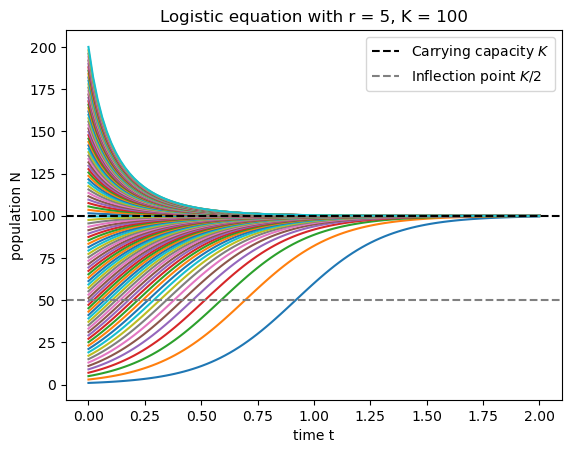

In [12]:
def logistic_equation(N, t, r, K):
    return r * N * (1 - N / K)
    
r = 5                         # birth rate 
K = 100                       # carrying capacity
N0 = np.linspace(1, 200, 100) # initial conditions
t = np.linspace(0, 2, 100)    # time axis
x = odeint(logistic_equation, N0, t, args=(r, K))

# plot solution
plt.plot(t, x)
plt.axhline(K, color='k', ls="--", label='Carrying capacity $K$')
plt.axhline(K/2, color='grey', ls="--", label='Inflection point $K/2$')
plt.xlabel('time t')
plt.ylabel('population N')
plt.legend()
plt.title('Logistic equation with r = {}, K = {}'.format(r, K))

So for $N(t) < K$ we observe an S-shaped or "sigmoid" curve. This is the reason why we call this the "logistic equation" as the solution has the form of the logistic function

$$
f(t) = \frac{K}{1 + \exp(-r (t - t_0))}
$$

Text(0.5, 1.0, 'Logistic function')

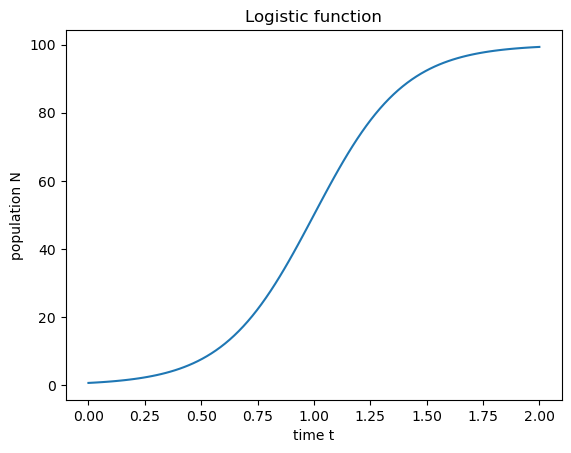

In [13]:
def logistic_function(t, r, K, t0):
    return K / (1 + np.exp(-r*(t - t0)))

plt.plot(t, logistic_function(t, r=r, K=K, t0=1))  # for N(t=0) which has the inflection point at t=1
plt.xlabel('time t')
plt.ylabel('population N')
plt.title('Logistic function')

## Linear Stability Analysis

We want to investigate the stability of fixed points in dynamical system of the form

$$
\dot{x} = f(x)
$$

So we don't further specify the right-hand side $f(x)$. The rate of decay (i.e. how quickly the system is converging) to a stable fixed point $x^*$ is obtained by linearizing the system about $x^∗$. Intuitively this should be the slope of $f$ at that fixed point.


$ $Let $\delta x(t) = x(t) - x^*$ be a *small perturbation* away from $x^*$. Differentiating $\delta x(t)$ gives

$$ \dot{\delta x} = \frac{d}{dt}(x - x^*) = \dot{x} $$

$ $since $x^*$ is constant.



Hence (via a Taylor expansion)

$$ \dot{\delta x} = f(x) = f(x^* + \delta x) $$
$$                = f(x^*) + \delta x f^{\prime}(x^*) + O(\delta x ^2) $$
$$                = \delta x f^{\prime}(x^*) + O(\delta x ^2) $$

$ $since $f(x^*) = 0$, 

thus

$$ \dot{\delta x} \simeq \delta x f^{\prime}(x^*) $$

$ $which is a *linear equation* in $\delta x$

The solutions to $$ \dot{\delta x} \simeq \delta x f^{\prime}(x^*) $$ 

describe exponential growth and decay, with characteristic timescale $|f'(x^*)|^{-1}$.

$ $The slope $f^{\prime}(x^*)$ at the fixed point determines its stability.

$ $$f^{\prime}(x^*) > 0$: fixed point is *unstable* - perturbations grow exponentially at a rate $f^{\prime}(x^*)$

$ $$f^{\prime}(x^*) < 0$: fixed point is *stable* - perturbations shrink exponentially at a rate $f^{\prime}(x^*)$

#### Example: Population Growth

$ $1) Using linear stability analysis, determine stability for the logistic equation model of population growth



#### Answer

The logistic equation of popultion $N$ is $\dot{N} = f(N) = rN\left(1 - \frac{N}{K}\right)$

__Fixed points__: The fixed points $N^*$ are derived from solving $f(N) = 0$,

$$f(N) = rN\left(1 - \frac{N}{K}\right) = 0 \Rightarrow N^* = 0, K$$

__Stability__: The stability is obtained from differentiating $f$ at the fixed points.

$$f^{\prime}(N^*) = r - \frac{2rN^*}{K} = \begin{cases}
r & \text{for} & N^* = 0 \\ 
-r & \text{for} & N^* = K \end{cases}$$

So from the sign we can conclude that

- $f'(N^* = 0) > 0$ so this fixed point is __unstable__.
- $f'(N^* = K) < 0$ so this fixed point is __stable__.


in both cases the slope is $\pm r$ so the characteristic timescale is its inverse, $1/r$. For the stable case that's the exponential "decay" towards the fixed point, and in the unstable case that's the exponential growth rate away from the fixed point.

Note that we could have already made the same conclusions from the graphical method above!

#### Example: Situations where $f^{\prime}(x^*) = 0$.

In the case where the derivative vanishes, we can have saddle points that are half stable. Compare

 $\dot{x} = -x^3$ and $\dot{x} = x^2$

 both have a fixed point at x = 0, and the derivative is zero too. But the first case of these fixed points is _stable_

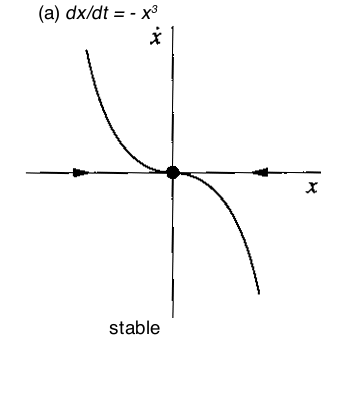

In [14]:
image_string = b'...'
display.Image(b64decode(image_string))

But the other one is _half-stable_, i.e. perturbations in one direction do not grow, while perturbations in the other direction do grow. This is a saddle point.

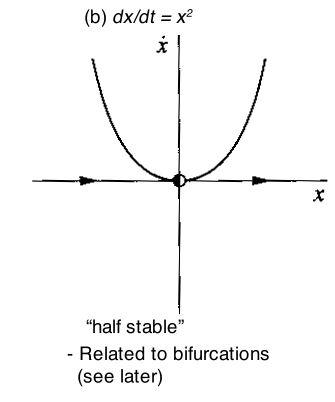

In [21]:
image_string = b'...'
display.Image(b64decode(image_string))

### Existence and Uniqueness

We need to beware of pathological cases. Consider the differential equation

$$ \dot{x} = \sqrt{x}, \quad x \geq 0 $$

Text(0, 0.5, '$\\dot{x}$')

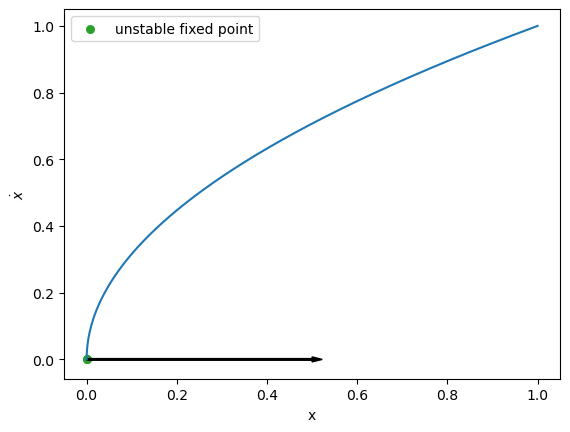

In [16]:
x = np.linspace(0, 1, 10000)
plt.plot(x, np.sqrt(x))
plt.scatter([0, 0], [0, 0], 30, color='C2', label='unstable fixed point')
plt.arrow(0, 0, dx=0.5, dy=0, width=0.005, color='k')
plt.xlabel('x')
plt.legend()
plt.ylabel(r'$\dot{x}$')

There is an unstable fixed point at $x^* = 0$ that leads to the solution (1)

$$x(t) = 0$$

but we can also find the solution (2)

$$x(t) = \frac{(t - c)^2}{4}$$

and the transition between solutions (1) and (2) can happen at any $c$. In that sense, even if the solution starts at $x(t=0) = 0$, it can always "branch off" to the quadratic solution of (2). Hence multiple solutions exist simulateously and uniqueness is not given. You may think of the fixed point $x^* = 0$ as "very unstable" as $f'(0) = \infty$. Because the derivative is not finite this has implications on the uniqueness of the solution.

You may wonder how this is different from "normal" unstable fixed points we considered before. Consider $\dot{x} = ax$
which also has a fixed point $x^* = 0$ but this time $f'(0) = a$ and therefore finite. A solution is $x(t) = 0$ (staying on the unstable fixed point) but the general solution is $x(t) = x_0 \exp(ax)$. Here we _need_ $x_0 \neq 0$ to come off the fixed point, for $x_0 = 0$ this general solution collapses to the specific solution we obtained from the fixed point. So in fact, both solutions agree with another and do not contradict. This is in contrast to the example before where two solutions (stay on fixed point, come off it) exist simultaneously.

We can illustrate these non-unique solutions with

Text(0.5, 1.0, 'Non-unique solutions in $\\dot{x} = \\sqrt{x}, x \\geq 0$')

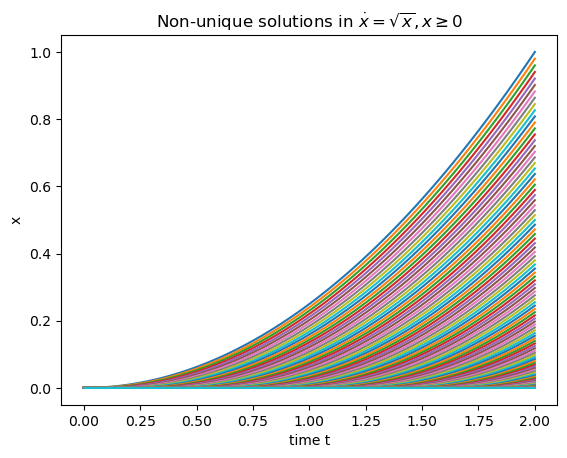

In [17]:
xx = np.zeros((len(t), len(t)))
for i, c in enumerate(t):
    xx[i, :] = np.minimum(0, t - c)**2 / 4    # choose x = 0 for t < c

plt.plot(t, xx)
plt.xlabel('time t')
plt.ylabel('x')
plt.title(r'Non-unique solutions in $\dot{x} = \sqrt{x}, x \geq 0$')

You may think that all these solutions are just very close and hence unique but feel free to change `plt.plot` to `plt.semilogy` and you will see that they actually "spontaneously grow" out of the unstable fixed point at any time! 

## Existence and Uniqueness Theorem

The previous example leads us to summarise theorems on existence and uniqueness. Consider $\dot{x} = f(x)$ with $x(0) = 0$.

__Peano existence theorem__: In essence this says that if $f(x)$ is continuous on an open interval $D$ of the real numbers $\mathbb{R}$ then there exists at least one solution on some time interval $(-\tau, \tau)$ around $t=0$.

__Picard-Lindelöf theorem__: In essence, if the derivative $f'(x)$ is also continuous then the solution is unique.

In other words ...

> If $f(x)$ is smooth enough, then solutions exist and are unique

And note that $\dot{x} = \sqrt{x}, \quad x \geq 0 $ violated the second theorem, hence explaining why we did not just find one unique solution.

#### Example

$\dot{x} = f(x) = 1+x^2$ with $x(0) = x_0$

$\bullet$ $f(x)$ and $f'(x)$ are continuous for all $x$, so solutions exist and are unique for any $x_0$.

$\bullet$ *but* they do not necessarily exist for all time ... !?

For example, consider $x_0 = 0 \rightarrow x(t) =$ tan $t$




This solution exists only for $- \pi/2 \lt t \lt \pi/2$ because $x(t) \rightarrow \pm \infty$ as $t \rightarrow \pm \pi/2$.

Thus for $|t| \gt \pi/2$, no solution exists given $x_0 = 0$

### Impossibility of oscillations in continuous 1D

There are no periodic solutions to the equation $\dot{x} = f(x)$ since $\dot{x} = f(x)$ corresponds to flow on a line. There is no memory, its an autonomous system and so you cannot overshoot a stable fixed point (for which you would need some "momentum"). Note that in the discrete case this is different as essentially take discrete steps which do allow you to "jump" over the stable fixed point -- causing an oscillation.

Hence, in continuous 1D: “You never come back to your starting place!”

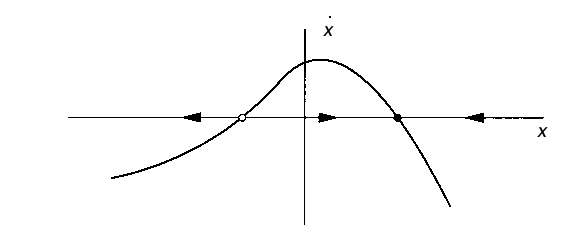

In [18]:
image_string = b'iVBORw0KGgoAAAANSUhEUgAAAkcAAADrCAYAAABjAjJLAAABJ2lDQ1BrQ0dDb2xvclNwYWNlQWRvYmVSR0IxOTk4AAAokWNgYFJILCjIYRJgYMjNKykKcndSiIiMUmB/xsDCIMPAwyDAwJ6YXFzgGBDgwwAEMBoVfLvGwAiiL+uCzMKUxwu4UlKLk4H0HyDOTi4oKmFgYMwAspXLSwpA7B4gWyQpG8xeAGIXAR0IZG8BsdMh7BNgNRD2HbCakCBnIPsDkM2XBGYzgeziS4ewBUBsqL0gIOiYkp+UqgDyvYahpaWFJol+IAhKUitKQLRzfkFlUWZ6RomCIzCkUhU885L1dBSMDIyMGBhA4Q5R/TkQHJ6MYmcQYgiAEJsjwcDgv5SBgeUPQsykl4FhgQ4DA/9UhJiaIQODgD4Dw745yaVFZVBjGJmMGRgI8QHvFUo94RqiBgAAAGxlWElmTU0AKgAAAAgABAEaAAUAAAABAAAAPgEbAAUAAAABAAAARgEoAAMAAAABAAIAAIdpAAQAAAABAAAATgAAAAAAAACWAAAAAQAAAJYAAAABAAKgAgAEAAAAAQAAAkegAwAEAAAAAQAAAOsAAAAAiwRY0QAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAGOZJREFUeAHt3TuLFNsWAODycjAUf4ZmgoKJGhgJgqGKmAr+AoNzA0HBXyEG/gVBMRFEUMRHbmRgZGZmYDDXmkOdu6bsR3V3Vdd+fMJh+rFr77W+VV17WTPOOXbw+0/jDwECBAgQIECAwKHAfzgQIECAAAECBAj8X0Bz9H8LjwgQIECAAAECjebISUCAAAECBAgQCAKao4DhIQECBAgQIEBAc+QcIECAAAECBAgEAc1RwPCQAAECBAgQIKA5cg4QIECAAAECBIKA5ihgeEiAAAECBAgQ0Bw5BwgQIECAAAECQUBzFDA8JECAAAECBAhojpwDBAgQIECAAIEgoDkKGB4SIECAAAECBDRHzgECBAgQIECAQBDQHAUMDwkQIECAAAECmiPnAAECBAgQIEAgCGiOAoaHBAgQ6AscO3asaf/zhwCBegQ0R/XUWqYECBAgQIDAAIG/BowxhAABAtUKHBwcVJu7xAnUKuDOUa2VlzcBAgQIECCwUEBztJDFiwQIECBAgECtApqjWisvbwIECBAgQGChgOZoIYsXCRAgQIAAgVoFNEe1Vl7eBAgQIECAwEIBzdFCFi8SIECAAAECtQpojmqtvLwJECBAgACBhQKao4UsXiRAoFaBW7duNadOnWpevHhxhODOnTvN6dOnm1evXh153RMCBMoT0ByVV1MZESCwg8DNmzebL1++NA8fPvx3lgcPHjSPHz9url+/3ly+fPnf1z0gQKBMgWO/f/urX/9aZm1lRYDAlgJnz55tPn/+3Lx+/br5/v17c+PGjeb27dvN06dPt5zRYQQI5CSgOcqpWmIlQOCIQPc/hB3773jPnj1rrl271pw5c+bwLtL58+ebly9fNsePHz+yvicECJQpoDkqs66yIlCFwFTNUYt37ty55tOnT4c/Z/T27dvm5MmTVZhKkgCBpvEzR84CAgQI9AS+fv3afPv27fDVEydOaIx6Pp4SKF1Ac1R6heVHgMBGAj9+/GiuXr16+C20CxcuNO/fv2+eP3++0RwGEyCQt4Bvq+VdP9ETqFpg7G+r/fr1q7ly5Urz7t275s2bN83Pnz+bixcvHn6L7cOHD1VbS55ATQLuHNVUbbkSILBS4O7du4e/x6j9Z/vtv1hr7xxdunSp+fjxY9P+kLY/BAjUIaA5qqPOsiRAYI3Ao0ePmidPnjT37t1r2l8E2f35+++/Dx/ev3+/e8lXAgQKF/BttcILLD0CJQuM/W21kq3kRoDAcAF3joZbGUmAAAECBAhUIKA5qqDIUiRAgAABAgSGC2iOhlsZSYAAAQIECFQgoDmqoMhSJECAAAECBIYLaI6GWxlJgAABAgQIVCCgOaqgyFIkQIAAAQIEhgtojoZbGUmAAAECBAhUIKA5qqDIUiRAgAABAgSGC2iOhlsZSYAAAQIECFQgoDmqoMhSJECAAAECBIYLaI6GWxlJgAABAgQIVCCgOaqgyFIkQIAAAQIEhgtojoZbGUmAAAECBAhUIKA5qqDIUiRAgAABAgSGC2iOhlsZSYAAAQIECFQgoDmqoMhSJECAAAECBIYLaI6GWxlJgAABAgQIVCCgOaqgyFIkQIAAAQIEhgtojoZbGUmAAAECBAhUIKA5qqDIUiRAgAABAgSGC2iOhlsZSYAAAQIECFQgoDmqoMhSJECAAAECBIYL/DV8qJEECBDIS+DYsWM7B3xwcLDzHCYgQCAvAc1RXvUSLQECKwTGaIb60/fn1Cz1hTwnUJ6A5qi8msqIQHUC/QamA9i1kVk0b/+1XdfoYvWVAIF0BI79/mC7Z5xOPURCgMAAgX6DEg+Z+pK2bO2p1405ekyAwLQCmqNpfc1OgMCIAqk1JqnFMyK1qQhULeBfq1VdfskTyEOgbUL6jUgKd2raGBbFsSjePKRFSYBAK+BnjpwHBAgkLZBiU9QHiw1SjLd7HN/vH+s5AQLpCWiO0quJiAgQ+C3QNRYdRi4NRhdnjL973L3X5eQrAQJpCvi2Wpp1ERWBagXaRqJrJjqEHJuKNuZ+3P28uvx8JUAgLQF3jtKqh2gIVC3Qbx76zUWOOF0OXW7d1+71HHMSM4HSBdw5Kr3C8iOQiUDXNLThto1Dac1DP58235hzJmUSJoEqBDRHVZRZkgTSFohNQr+JSDvyzaJb1PTF3DebzWgCBKYS0BxNJWteAgTWCvTvnpTcGEWMfp4apKjjMYH5BTRH89dABASqFOg3BP2GoXSU/l2kfqNYev7yI5CygOYo5eqIjUChArEx6jcJhaa8NK1+Uxhtlh7kDQIEJhXQHE3Ka3ICBPoCcfPvNwb9sbU87zeI0agWA3kSSElAc5RSNcRCoHCBuOlrjP4sdjRpraLXn6O9QoDAVAKao6lkzUuAwBGBuNHHJuDIIE/++BUG0Q0PAQL7EdAc7cfZKgSqFogbvMZo/anQGkWn6Lf+aCMIENhVQHO0q6DjCRBYKRA39rjhrzxogzenmHOD5ScdGnOLjpMuanICBBrNkZOAAIHJBOKGHjf6MReMa4w5bypzRbfSc03FXBwENEfOAQIEJhGIG3nc4CdZrPBJo190LTxt6RGYTUBzNBu9hQmUKxA38LixT5Hx1PNPEfM2c8Y8W99ovM18jiFAYLmA5mi5jXcIENhCIG7acUPfYiqH9AT6ntG6N9RTAgR2ENAc7YDnUAIECOxboG2QYpOkQdp3BaxXg4DmqIYqy5HAngTiRh038CmXj2tOuU5qc0ffWg1Sq4l4yhHQHJVTS5kQmFUgbtBx4541qMIXj87Rv/C0pUdgcgHN0eTEFiBQvkDcmOOGXX7m82cYvWMd5o9MBATyFdAc5Vs7kRNIQiBuyHGjTiK4SoKI7rEelaQvTQKjC2iORic1IYF6BOJGHDfofQrMte4+cxyyVnSIdRlyrDEECBwV0Bwd9fCMAIGBAnEDjhvzwMMNm0Ag1iHWZ4KlTEmgaAHNUdHllRyBaQTixhs35GlWM+smArEesU6bzGEsgdoFNEe1nwHyJ7ChQNxw40a84TSjDY/xjDZp5hPFuvDJvJjCn0VAczQLu0UJ5CkQN9q4AeeZTdlRx/rEupWdtewIjCOgORrH0SwEiheIG2zceItPPOMEY51i/TJOSegE9iKgOdoLs0UI5C0QN9a44eadVR3Rx3rFOtaRvSwJbCegOdrOzVEEqhGIG2rcaFMBSDGmVGzEQYDAdgKao+3cHEWgCoHUG6MqijBCkrGBjDUdYWpTEChSQHNUZFklRWB3gbiJxs1195nNMIdArGGs7RyxWJNA6gKao9QrJD4CMwjEzTNuqjOEYskRBWItY41HXMJUBIoQ0BwVUUZJEBhPIG6acTMdb4VxZ4rxjjtzmbPFmrIrs8ay2l1Ac7S7oRkIFCMQN8u4iaacYC5xpmQYzWLNU4pRLATmFNAczalvbQIJCcRNMm6eCYW4MJQY98IBXlwoEGvMcCGRFysW0BxVXHypE+gE4uYYN83u/ZS/5hZvSpbsUqqGWFIS0BylVA2xEJhBIOfGaAauYpeM50GxSUqMwEABzdFAKMMIlCbQboZxQ3QXobQKD8sn1j2eD8OONopAmQKaozLrKisCKwX6m2DcIFce6M0iBWL9++dGkQlLisAaAc3RGiBvEyhNIG5+7aYYN8bScpXPcIF4HsRzZPgMRhIoR0BzVE4tZUJgrUDc9OJmuPZAA6oQcE5UUWZJDhDQHA1AMoRACQIaoxKqOH0OXYMUz5fpV7UCgbQENEdp1UM0BCYRiBtdt/lNspBJixKI501RiUmGwBoBzdEaIG8TyF0gbnAao9yruZ/443kSz5/9rG4VAvMLaI7mr4EICEwi0G5qcWOLG94kC5q0KAHnS1HllMyGApqjDcEMr0sgNhc5ZR7jbjc5G11O1Usn1u68iedTOtGJhMB0An9NN7WZCeQnUMImEHPoNrf8KjF9xNGpXY3VavPWi9Fqo03fdQ5uKra/8Zqj/VlbKUGB/sUpwRBXhrQqfhvZSro/3uxb8vuHqHXobLqvHR6jTmLY177fsKOMmkNAczSHujVnEyjp4tTlEjeoRa/Nhp35wp1ll0Z07l6r/WtrxGX5WdA/h5aP9E5qApqj1CoinlEFSr04dXn1N6b2effeqJAJT9bm23dYF+42Rv1jNl1zXUzez1+gf47kn1G9GRz7/QE/qDf9PzN3cv9p4pU0BZZ9dJ3DadZLVAQIHBVYdg07OmqeZ+4c9dxTLlYvVE8HCIzRKKR4TrR5tf8ti23Z6wPIshrS1XfTfLvjdk1203V3XW+O44dY1eCwzH6Iz7Jjl72+yrNdr31/1brx+HXjlr3fzTFkvWV5rHq9m3/VmDnfc+doTn1r711g2YVgVSApfoi7PPqxLXt9VX45v9dduLfJobPa5Ni+9ybH5jx2lVWtJqvqucpr1XEsV+ns9z13jvbrbbWZBfoXn20vYnOl0Y+3/7yNq5/jXLGWsC7Lf6rYOiw610qo8RQ59M8bdlMoTzun5mhaX7MnLpDTRax/ge1ij693ryXOPnt40SwGwy9qHH3c2ixya1/jdtSq/6zvs8ixf4zn8wr4ttq8/lYnMEggXkz7F9pBExQ6aJeNeZdjC+XcOC3n5cZkCw/oHH22F/LM8qI7R7OwW5TAMIHuotmNdvHsJHb/ynIcw/45uvus9c3gXEyv5v7faunVREQEDgX6m44LqBMjZYH++ZpyrGIjsE5Ac7ROyPsEZhCIG03bFGmMZiiCJQcJODcHMRmUmYDmKLOCCbdsgbYp6jdGZWcsuxIEugYpnrsl5CWHegU0R/XWXuaJCfQ3lm7DSSxM4RBYKdA/j1cO9mY1Ardu3WpOnTrVvHjx4kjOd+7caU6fPt28evXqyOtzP9EczV0B6xP4LRA3lLYp0hg5LXITiOdsPJ9zy0O80wjcvHmz+fLlS/Pw4cN/F3jw4EHz+PHj5vr1683ly5f/fT2FB/4pfwpVEEO1Av1NJG4w1aJskHjrx2wDsD0M7c5pddkDdmZLnD17tvn8+XPz+vXr5vv3782NGzea27dvN0+fPk0uE81RciURUC0C3SbS5Wsz6SSGf9UcDbfa18h4Xjun96WexzrPnj1rrl271pw5c+bwLtL58+ebly9fNsePH08uAc1RciURUOkCcfNoc7WBbF9xzdH2dlMeGc9x5/eU0vnNfe7cuebTp0+HP2f09u3b5uTJk0km4WeOkiyLoEoViJtGm6ONo9RK152X87ru+i/L/uvXr823b98O3z5x4kSyjVEboOZoWRW9TmBEgbYpio1Ru3nYQEYENlWyAvG8TzZIgU0u8OPHj+bq1auH30K7ePFi8/79++b58+eTr7vtAr6ttq2c4wgMFOhvDpqigXADhrW2PAdAzTQknvvqNFMRElj2169fzZUrV5p37941b968aX7+/Nm0DVL7LbYPHz4kEOGfIbhz9KeJVwiMItBuDP3NwQYxCq1JMhFwvmdSqInDvHv37uHvMWr/2X77L9YuXLjQXLp0qfn48WPT/pB2in80RylWRUxZC2iKsi6f4CcSiH9RmGgJ0yYo8OjRo+bJkyfNvXv3mvYXQXZ//vvf/x4+vH//fvdSUl99Wy2pcggmd4H+BuBvztNWtPVmPK3xGLPHz4V6jSFqjqkF/pp6AfMTqEEgXvzbfG0ANVRdjkMF2s9D/zMy9FjjCMwh4Ntqc6hbsxiB9oLfv+hrjIopr0QmEOh/XiZYwpQEdhbQHO1MaIJaBfoX+bYp0hjVejbIe52Az8Y6Ie+nJKA5SqkaYslCoH+3SFOURdkEmYBA1yD1/2KRQGhCIHBEQHN0hMMTAqsF+hf17mK/+ijvEiDQF+h/lvrve05gTgE/kD2nvrWzEehfyDVF2ZROoIkJtJ+d/ucpsRCFQ8D/PsQ5QGCVQHsRjxfy9sKuMVol5j0C6wW6z1D8bK0/yggC+xNw52h/1lbKSKB/0e4u5hmlIFQCWQi0nzWfryxKVVWQfuaoqnJLdp1Ae6HWGK1T8j6B3QU0RLsbmmE6AXeOprM1c0YC/YaoDd3FO6MCCjVrAXePsi5fkcFrjoosq6SGCmiKhkoZR2B8gfYvIIs+g+OvZEYCmwn4ttpmXkYXItBekPsX5fZC7W5RIQWWRjYC3Weu/3nMJgGBFingzlGRZZXUMoFFF+Du4rzsGK8TILAfgfbz6fO4H2urrBbQHK328W4hApqiQgopjSIF2oZo0We0yGQllYWA5iiLMglyW4FFF1x/M91W03EEphdw92h6YyusF/AzR+uNjMhQoL3A9hujtinSGGVYTCFXIRA/m/3PbhUAkkxKwJ2jpMohmF0FFl1U40V31/kdT4DAdALtZ3XRZ3i6Fc1MYLGA5mixi1czE1h0QdUUZVZE4RIIAu1n2mc4gHi4VwHN0V65LTa2gKZobFHzEZhXwN2jef2t/o+A5siZkJ3AooaoTcLfMrMrpYAJrBRw92gljzcnFPAD2RPimnpcgfZCuagxapsijdG41mYjMKdA/Dwv+szPGZu16xBw56iOOmed5aKLY7x4Zp2c4AkQWCjQfsYXffYXDvYigZEFNEcjg5puHIFlF0VN0Ti+ZiGQk0B7PfDZz6li+ceqOcq/hkVlsKgpclEsqsSSITBYwN2jwVQGjiygORoZ1HSbCyxqiNpZNEWbWzqCQKkC7h6VWtk089IcpVmXKqLSFFVRZkkS2EnA3aOd+By8pYDmaEs4h20noCHazs1RBAg0hz+g7Y6yM2EfApqjfShXvsayhqhlcaGr/OSQPoEBAu4eDUAyZFQBzdGonCbrBDREnYSvBAiMIdA1SO21xV+qxhA1xyoBzdEqHe9tJKAh2ojLYAIECBBIVEBzlGhhcglLQ5RLpcRJIH8Bd4/yr2EuGWiOcqlUQnFqiBIqhlAIVCrg22uVFn5PaWuO9gSd+zIaotwrKH4CZQh0d4/KyEYWqQpojlKtTAJxaYgSKIIQCBBYKuDu0VIab+wooDnaEbCkw1c1Q22e/oVISdWWC4F8Bdw9yrd2uUSuOcqlUhPEqRmaANWUBAjsVcDdo71yV7OY5qiaUv/z22XXpevu0Doh7xMgkIKAu0cpVKHcGDRH5db28Fftr0tPM7ROyPsECKQq0DVI7h6lWqF849Ic5Vu7I5Gv+xZZN1gz1En4SoBASQIapJKqOX8umqP5a7B1BOsaIo3Q1rQOJEAgE4Hu7lEm4QozEwHNUSaFGhKmZmiIkjEECJQq4O5RqZXdf16ao/2bj7aiZmg0ShMRIJCxgLtHGRcv0dD/k2hcwiJAgAABAhsLrPtxg40ndECVApqjKssuaQIECJQl4E56WfWcOxvN0dwVsD4BAgQIjCrg7tGonFVOpjmqsuySJkCAQHkC7h6VV9O5MtIczSVvXQIECBAYXaBrkNw9Gp22qgk1R1WVW7IECBCoR0CDVE+tx85UczS2qPkIECBAYFaB7u7RrEFYPGsBzVHW5RM8AQIECBAgMLaA5mhsUfMRIECAwOwC3d0j31qbvRRZBqA5yrJsgiZAgACBoQIapKFSxnUCmqNOwlcCBAgQKEqgu3tUVFKS2YuA5mgvzBYhQIAAgTkF3D2aUz+/tTVH+dVMxAQIECAwUMDdo4FQhh0R0Bwd4fCEAAECBEoVcPeo1MqOn5fmaHxTMxIgQIBAQgLuHiVUjExC0RxlUihhEiBAgMDuAu4e7W5YwwyaoxqqLEcCBAhULuDuUeUnwIbpa442BDOcAAECBPIWcPco7/rtI3rN0T6UrUGAAAECswu4ezR7CbIJQHOUTakESoAAAQK7CnQNkrtHu0qWfbzmqOz6yo4AAQIECBDYUEBztCGY4QQIECCQt4C7R3nXbx/Ra472oWwNAgQIECBAIBsBzVE2pRIoAQIECIwl4O7RWJJlzqM5KrOusiJAgAABAgS2FNAcbQnnMAIECBDIW8Ddo7zrN2X0mqMpdc1NgAABAgQIZCfwV3YRC5gAAQIECIwk0N09Gmk60xQi4M5RIYWUBgECBAgQIDCOgOZoHEezECBAgAABAoUIaI4KKaQ0CBAgQIAAgXEENEfjOJqFAAECBAgQKERAc1RIIaVBgAABAgQIjCOgORrH0SwECBAgQIBAIQKao0IKKQ0CBAgQIEBgHAHN0TiOZiFAgAABAgQKEdAcFVJIaRAgQIAAAQLjCGiOxnE0CwECBAgQIFCIgOaokEJKgwABAgQIEBhHQHM0jqNZCBAgQIAAgUIENEeFFFIaBAgQIECAwDgCmqNxHM1CgAABAgQIFCKgOSqkkNIgQIAAAQIExhHQHI3jaBYCBAgQIECgEAHNUSGFlAYBAgQIECAwjoDmaBxHsxAgMIPAwcHBDKtakgCB0gU0R6VXWH4ECBAgQIDARgKao424DCZAgAABAgRKF9AclV5h+REgQIAAAQIbCWiONuIymAABAgQIEChdQHNUeoXlR4AAAQIECGwkoDnaiMtgAgQIECBAoHQBzVHpFZYfAQIECBAgsJGA5mgjLoMJECBAgACB0gU0R6VXWH4ECBAgQIDARgL/A6yD1Rg1j0s+AAAAAElFTkSuQmCC'
display.Image(b64decode(image_string))